# Trabajo de Clasificación Binaria — Predicción de abandono de clientes (churn)
**Módulo: Machine Learning — Máster en Big Data, Data Science e IA**

**Contexto del problema.** Una empresa de telecomunicaciones desea anticipar la pérdida de clientes. Disponemos de 20 variables independientes (V1–V20) con métricas de uso del servicio, y una variable dependiente **Y** que codifica si el cliente abandonó (Y=1) o no (Y=0). Es, por tanto, un **problema supervisado de clasificación binaria**.

**Metodología (siguiendo los pasos vistos en teoría):**
1. **EDA**: visualización del dataset e identificación de la target, tipos de variables, estadísticos descriptivos.
2. **Cleaning**: análisis de *missing* (detección, % por variable, patrones y mecanismo MCAR/MAR/MNAR) y de *outliers* (detección visual y estadística, impacto y decisión).
3. Balanceo de clases y **relaciones entre variables** (sobre todo con la target).
4. **Feature Engineering**: transformaciones justificadas para SVM.
5. **SVM** con dos kernels (lineal y RBF), búsqueda de hiperparámetros con validación cruzada, evaluación con **accuracy** y **AUC**, representación gráfica de la búsqueda, comparación de los dos mejores modelos y elección razonada del ganador.

In [72]:
# =====================================================
# 0. LIBRERÍAS
# =====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

SEED = 12345
np.random.seed(SEED)

---
## 1. EDA — Análisis Exploratorio de Datos

Tal y como se describe en los apuntes de clase:

> *"El EDA es la fase del análisis de datos cuyo objetivo principal es conocer, comprender y validar los datos antes de aplicar modelos de ML"* (teoría del módulo).

### 1.1. Carga y visualización del dataset. Identificación de la variable objetivo

In [73]:
# Carga del dataset (ajustar el separador/decimal si fuera necesario)
df = pd.read_csv(r'C:\Users\carlo\OneDrive\Desktop\MASTER_BIG_DATA_DATA_SCIENCE_IA\MASTER_BIG_DATA_DATA_SCIENCE_IA\SVM_ENSEMBLERS\Tarea 2026 feb presencial\BBDD_ML_TAREA.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head(10)

Dimensiones del dataset: 9200 filas x 21 columnas


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,Y
0,43,121,415.0,1118,0,0,0,86.1,100,14.64,259.8,113,22.08,148.0,79.0,6.66,9.1,9,2.46,2,0
1,7,170,510.0,3326,0,0,0,184.1,106,31.30,204.9,70,17.42,224.3,133.0,10.09,9.8,3,2.65,2,0
2,31,96,510.0,2146,0,0,0,150.0,122,25.50,218.5,116,18.57,212.4,89.0,9.56,9.8,1,2.65,3,0
3,17,90,415.0,387,0,0,0,193.7,83,32.93,154.2,79,13.11,299.0,60.0,13.46,12.7,3,3.43,1,0
4,7,61,415.0,313,0,0,0,140.6,89,23.90,172.8,128,14.69,212.4,97.0,9.56,13.6,4,3.67,1,0
5,45,104,415.0,3280,0,0,0,139.7,112,23.75,199.8,127,16.98,189.3,104.0,8.52,10.3,2,2.78,2,0
6,32,93,415.0,380,0,0,0,239.8,70,40.77,251.8,99,21.40,168.6,112.0,7.59,10.9,10,2.94,1,0
7,5,88,510.0,2384,0,0,0,61.9,78,10.52,262.6,114,22.32,212.5,110.0,9.56,8.8,2,2.38,3,0
8,15,81,415.0,3186,0,0,0,176.1,113,29.94,162.0,80,13.77,160.9,83.0,7.24,11.9,4,3.21,1,0
9,49,130,510.0,374,0,0,0,110.0,107,18.70,181.9,85,15.46,208.0,94.0,9.36,11.7,3,3.16,1,0


In [74]:
# Vista general de la estructura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      9200 non-null   int64  
 1   V2      9200 non-null   int64  
 2   V3      9125 non-null   float64
 3   V4      9200 non-null   int64  
 4   V5      9200 non-null   int64  
 5   V6      9200 non-null   int64  
 6   V7      9200 non-null   int64  
 7   V8      9200 non-null   float64
 8   V9      9200 non-null   int64  
 9   V10     9174 non-null   float64
 10  V11     9200 non-null   float64
 11  V12     9200 non-null   int64  
 12  V13     9200 non-null   float64
 13  V14     9128 non-null   float64
 14  V15     9140 non-null   float64
 15  V16     9200 non-null   float64
 16  V17     9200 non-null   float64
 17  V18     9200 non-null   int64  
 18  V19     9156 non-null   float64
 19  V20     9200 non-null   int64  
 20  Y       9200 non-null   int64  
dtypes: float64(10), int64(11)
memory usag

**Identificación de la variable objetivo.** La variable dependiente es **Y**, que codifica el abandono del cliente:
- **Y = 1** → el cliente ha abandonado el servicio (*churn*), clase positiva que queremos detectar.
- **Y = 0** → el cliente permanece.

Las 20 variables restantes (V1–V20) son las independientes. Según el diccionario de datos del enunciado:

| Var | Detalle | Var | Detalle |
|---|---|---|---|
| V1 | Estado/región del cliente | V11 | Minutos totales llamadas vespertinas |
| V2 | Duración de la cuenta | V12 | Nº llamadas vespertinas |
| V3 | Código de área telefónica | V13 | Coste total llamadas vespertinas |
| V4 | Número de teléfono | V14 | Minutos totales llamadas nocturnas |
| V5 | Plan internacional (sí/no) | V15 | Nº llamadas nocturnas |
| V6 | Plan buzón de voz (sí/no) | V16 | Coste total llamadas nocturnas |
| V7 | Nº mensajes de buzón de voz | V17 | Minutos totales llamadas internacionales |
| V8 | Minutos totales llamadas diurnas | V18 | Nº llamadas internacionales |
| V9 | Nº llamadas diurnas | V19 | Coste total llamadas internacionales |
| V10 | Coste total llamadas diurnas | V20 | Nº llamadas al servicio de atención |

Y
0    4600
1    4600
Name: count, dtype: int64

Proporciones:
Y
0    0.5
1    0.5
Name: proportion, dtype: float64


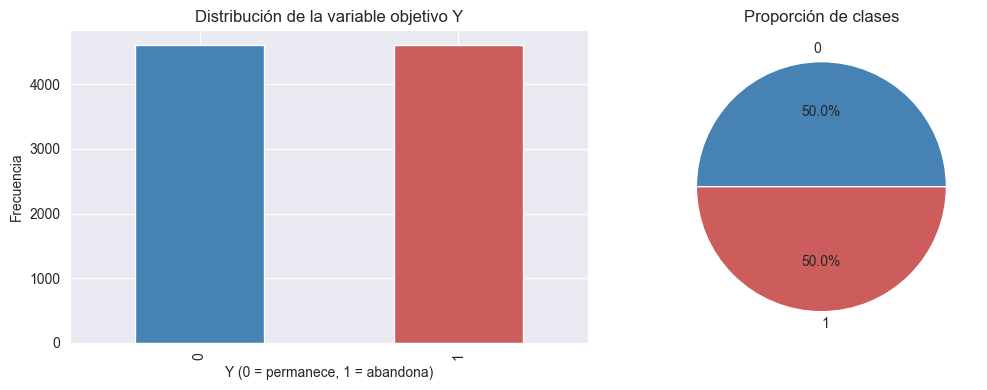

In [75]:
# Distribución de la variable objetivo (balanceo de datos, punto 5 del EDA de teoría)
print(df['Y'].value_counts())
print('\nProporciones:')
print(df['Y'].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['Y'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'], ax=ax[0])
ax[0].set_title('Distribución de la variable objetivo Y')
ax[0].set_xlabel('Y (0 = permanece, 1 = abandona)'); ax[0].set_ylabel('Frecuencia')
df['Y'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1],
                            colors=['steelblue', 'indianred'])
ax[1].set_title('Proporción de clases'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

En este tipo de datasets de churn la clase positiva (abandono) suele rondar el **10-20%**, es decir, suele existir un **desbalanceo moderado**. Consecuencias metodológicas:
- El *accuracy* por sí solo puede ser engañoso (un modelo que prediga siempre Y=0 acertaría ~85%). Por eso el enunciado exige también **AUC**, que es insensible al desbalanceo.
- Usaremos **muestreo estratificado** en el train/test split y en la validación cruzada para preservar la proporción de clases.
- Probaremos `class_weight='balanced'` en el SVM como hiperparámetro adicional.

Sin embargo, sorprendetemente, este dataset no está desbalanceado por lo que tendremos más facilidad durante el entrenamiento. De todas formas, procederemos de la forma más general realizando todos los pasos para que, en caso de cambiar el dataset y tener una situación desbalanceada, poder reutilizar el código. Primero, estudiaremos si existen duplicados porque parece que el dataset ha sido previamente balanceado, pero no hemos dividido en train y en test todavía, luego podemos tener problemas de overfitting. El balanceo lo haremos en caso de necesitarlo en el conjunto de train.

In [76]:
# 1. Verificamos cuántas filas duplicadas existen antes de limpiar
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {n_duplicados}")

# 2. Eliminamos filas duplicadas (conserva la primera aparición) y reajustamos el índice
df = df.drop_duplicates().reset_index(drop=True)

# 3. Dimensiones actualizadas
print(f"Dimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas")

Filas duplicadas encontradas: 5662
Dimensiones finales: 3538 filas x 21 columnas


En efecto, más de la mitad del dataset estaba duplicado, lo que podría llevar a riesgos metodológicos graves. Una vez eliminados los duplicados, vemos la distribución real del abandono entre nuestros clientes.

Y
0    2832
1     706
Name: count, dtype: int64

Proporciones:
Y
0    0.8005
1    0.1995
Name: proportion, dtype: float64


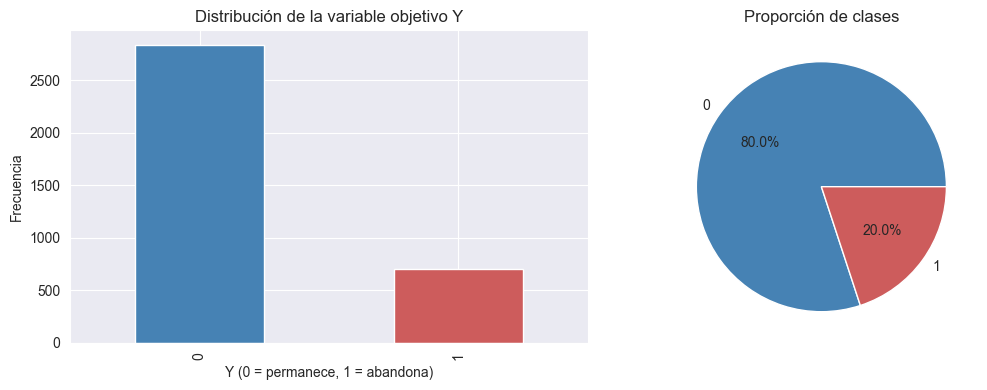

In [77]:
# Distribución de la variable objetivo (balanceo de datos, punto 5 del EDA de teoría)
print(df['Y'].value_counts())
print('\nProporciones:')
print(df['Y'].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['Y'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'], ax=ax[0])
ax[0].set_title('Distribución de la variable objetivo Y')
ax[0].set_xlabel('Y (0 = permanece, 1 = abandona)'); ax[0].set_ylabel('Frecuencia')
df['Y'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1],
                            colors=['steelblue', 'indianred'])
ax[1].set_title('Proporción de clases'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

Ahora sí cumplimos con lo usual en nuestro dataset y podemos empezar a trabajar con el conjunto de datos. Si hubiésemos continuado como anteriormente, podríamos haber tenido casos duplicados en el conjunto de test y en el conjunto de train, luego haber sobreajustado y no habernos dado cuenta del error que podríamos haber cometido.

### 1.2. Tipos de variables y su correcta clasificación

Aunque pandas infiera un tipo (int/float/object), la clasificación **conceptual** correcta es la que determina el tratamiento:

| Variable | Tipo pandas | Tipo conceptual | Tratamiento |
|---|---|---|---|
| V1 (estado) | object | **Categórica nominal** (~51 categorías) | Codificación / agrupación |
| V2 (antigüedad) | int | Numérica discreta (cuenta) | Estandarizar |
| V3 (cód. área) | int/object | **Categórica nominal** ⚠️ aunque sea numérica, es un código: no tiene sentido ordinal ni de magnitud | One-hot |
| V4 (nº teléfono) | object | **Identificador** único | **Eliminar** (sin valor predictivo, riesgo de sobreajuste) |
| V5, V6 (planes) | object | Categóricas **binarias** | Mapear a 0/1 |
| V7 | int | Numérica discreta | Estandarizar |
| V8–V19 | float/int | Numéricas continuas (minutos, costes) y discretas (nº llamadas) | Estandarizar |
| V20 | int | Numérica discreta (cuenta) | Estandarizar |
| Y | int | **Binaria — TARGET** | — |

In [78]:
# Comprobación empírica de los tipos y cardinalidad
resumen_tipos = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unicos': df.nunique(),
    'ejemplos': [df[c].dropna().unique()[:4] for c in df.columns]
})
resumen_tipos

,dtype,n_unicos,ejemplos
V1,int64,51,"[43, 7, 31, 17]"
V2,int64,214,"[121, 170, 96, 90]"
V3,float64,3,"[415.0, 510.0, 408.0]"
V4,int64,3536,"[1118, 3326, 2146, 387]"
V5,int64,2,"[0, 1]"
V6,int64,2,"[0, 1]"
V7,int64,46,"[0, 12, 42, 36]"
V8,float64,1744,"[86.1, 184.1, 150.0, 193.7]"
V9,int64,118,"[100, 106, 122, 83]"
V10,float64,1742,"[14.64, 31.3, 25.5, 32.93]"


In [79]:
# Clasificación de las variables según el análisis anterior
var_id          = ['V4']                    # identificador -> se eliminará
var_cat_nominal = ['V1', 'V3']              # categóricas nominales
var_cat_binaria = ['V5', 'V6']              # binarias sí/no
var_target      = 'Y'
var_numericas   = ['V2', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13',
                   'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20']

# V3 (código de área): aunque llegue como número, la convertimos a categórica
df['V3'] = df['V3'].astype(str)

print('Identificador:', var_id)
print('Categóricas nominales:', var_cat_nominal)
print('Categóricas binarias:', var_cat_binaria)
print('Numéricas:', var_numericas)

Identificador: ['V4']
Categóricas nominales: ['V1', 'V3']
Categóricas binarias: ['V5', 'V6']
Numéricas: ['V2', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20']


### 1.3. Estadísticos descriptivos

In [80]:
# Descriptivos de las variables numéricas, incluyendo asimetría y curtosis
desc = df[var_numericas].describe().T
desc['asimetria'] = df[var_numericas].skew()
desc['curtosis'] = df[var_numericas].kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis
V2,3538.0,100.676,39.697,1.0,73.000,100.00,126.000,243.00,0.140,-0.043
V7,3538.0,7.587,13.454,0.0,0.000,0.00,15.000,52.00,1.382,0.278
V8,3538.0,181.799,55.501,0.0,144.425,181.10,218.675,351.50,0.015,-0.059
V9,3538.0,100.227,19.778,0.0,88.000,100.00,114.000,160.00,-0.086,0.109
V10,3525.0,30.928,9.431,0.0,24.570,30.82,37.210,59.76,0.016,-0.061
V11,3538.0,200.772,51.026,22.3,165.900,202.00,235.300,363.70,-0.034,0.016
V12,3538.0,100.578,19.615,12.0,88.000,100.00,114.000,170.00,0.028,0.089
V13,3538.0,17.066,4.337,1.9,14.100,17.17,20.000,30.91,-0.034,0.015
V14,3512.0,200.782,50.595,0.0,167.300,200.45,235.300,395.00,0.027,0.111
V15,3510.0,99.675,20.080,0.0,86.000,100.00,113.000,175.00,0.017,0.118


In [81]:
# Descriptivos de las variables categóricas
for c in var_cat_nominal + var_cat_binaria:
    print(f'--- {c} ---')
    vc = df[c].value_counts()
    print(f'Nº de categorías: {vc.shape[0]}')
    print(vc.head(8), '\n')

--- V1 ---
Nº de categorías: 51
V1
49    105
23     92
43     91
13     88
1      88
34     84
50     82
31     81
Name: count, dtype: int64 

--- V3 ---
Nº de categorías: 4
V3
415.0    1758
408.0     873
510.0     872
nan        35
Name: count, dtype: int64 

--- V5 ---
Nº de categorías: 2
V5
0    3152
1     386
Name: count, dtype: int64 

--- V6 ---
Nº de categorías: 2
V6
0    2624
1     914
Name: count, dtype: int64 



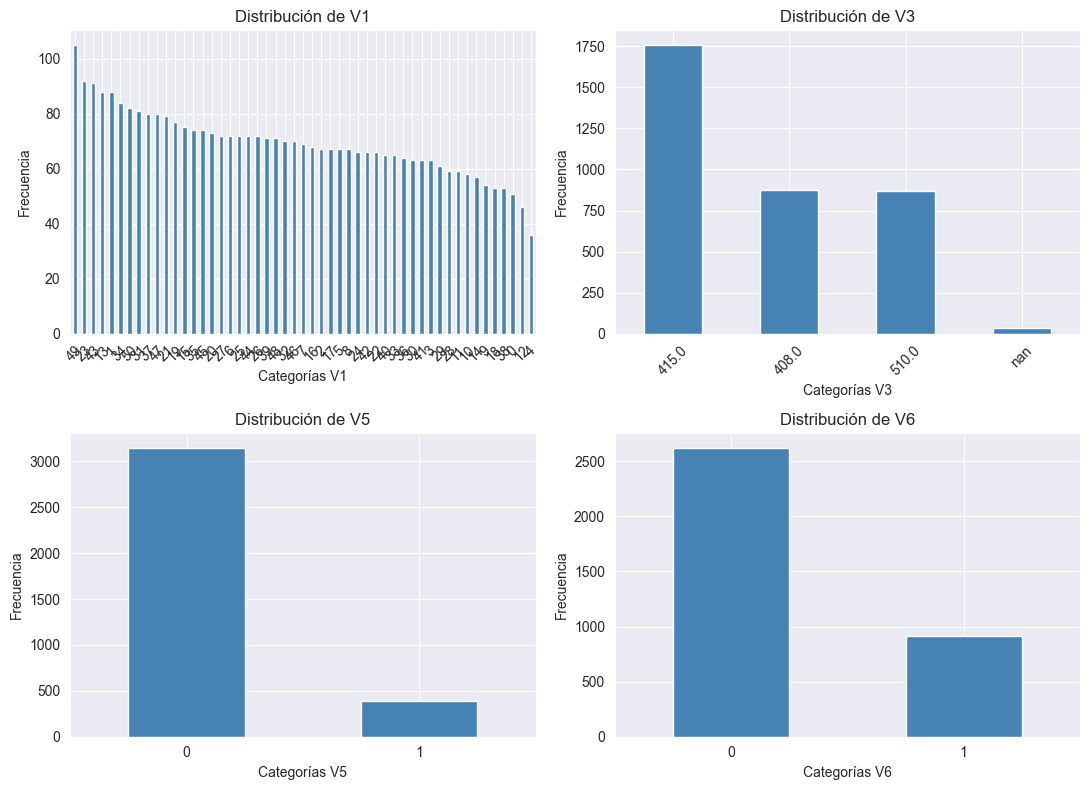


                      RESUMEN DE DATOS                      

V1 - N.º de categorías: 51
V1
49    105
23     92
43     91
13     88
1      88
34     84
50     82
31     81
37     80
47     80
21     79
19     77
15     75
35     74
45     74
20     73
27     72
6      72
25     72
44     72
26     72
39     71
48     71
32     70
46     70
7      69
16     68
2      67
17     67
5      67
8      67
24     66
42     66
22     66
40     65
33     65
36     64
30     63
41     63
3      63
29     61
28     59
11     59
10     58
14     57
9      54
18     53
38     53
0      51
12     46
4      36
Name: count, dtype: int64
Total: 3538

V3 - N.º de categorías: 4
V3
415.0    1758
408.0     873
510.0     872
nan        35
Name: count, dtype: int64
Total: 3538

V5 - N.º de categorías: 2
V5
0    3152
1     386
Name: count, dtype: int64
Total: 3538

V6 - N.º de categorías: 2
V6
0    2624
1     914
Name: count, dtype: int64
Total: 3538



In [82]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Obtener frecuencias de las variables
v1 = df['V1'].value_counts(dropna=False)
v3 = df['V3'].value_counts(dropna=False)
v5 = df['V5'].value_counts(dropna=False)
v6 = df['V6'].value_counts(dropna=False)

# 2. Crear figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# --- V1 ---
v1.plot(kind='bar', color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de V1')
axes[0, 0].set_xlabel('Categorías V1')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].tick_params(axis='x', rotation=45)

# --- V3 ---
v3.plot(kind='bar', color='steelblue', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de V3')
axes[0, 1].set_xlabel('Categorías V3')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].tick_params(axis='x', rotation=45)

# --- V5 ---
v5.plot(kind='bar', color='steelblue', ax=axes[1, 0])
axes[1, 0].set_title('Distribución de V5')
axes[1, 0].set_xlabel('Categorías V5')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].tick_params(axis='x', rotation=0)

# --- V6 ---
v6.plot(kind='bar', color='steelblue', ax=axes[1, 1])
axes[1, 1].set_title('Distribución de V6')
axes[1, 1].set_xlabel('Categorías V6')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('frecuencias_grafico.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Impresión del resumen en consola
print("\n" + "="*60)
print("RESUMEN DE DATOS".center(60))
print("="*60)

for nombre, serie in zip(['V1', 'V3', 'V5', 'V6'], [v1, v3, v5, v6]):
    print(f"\n{nombre} - N.º de categorías: {len(serie)}")
    print(serie)
    print(f"Total: {serie.sum()}")

print("\n" + "="*60)

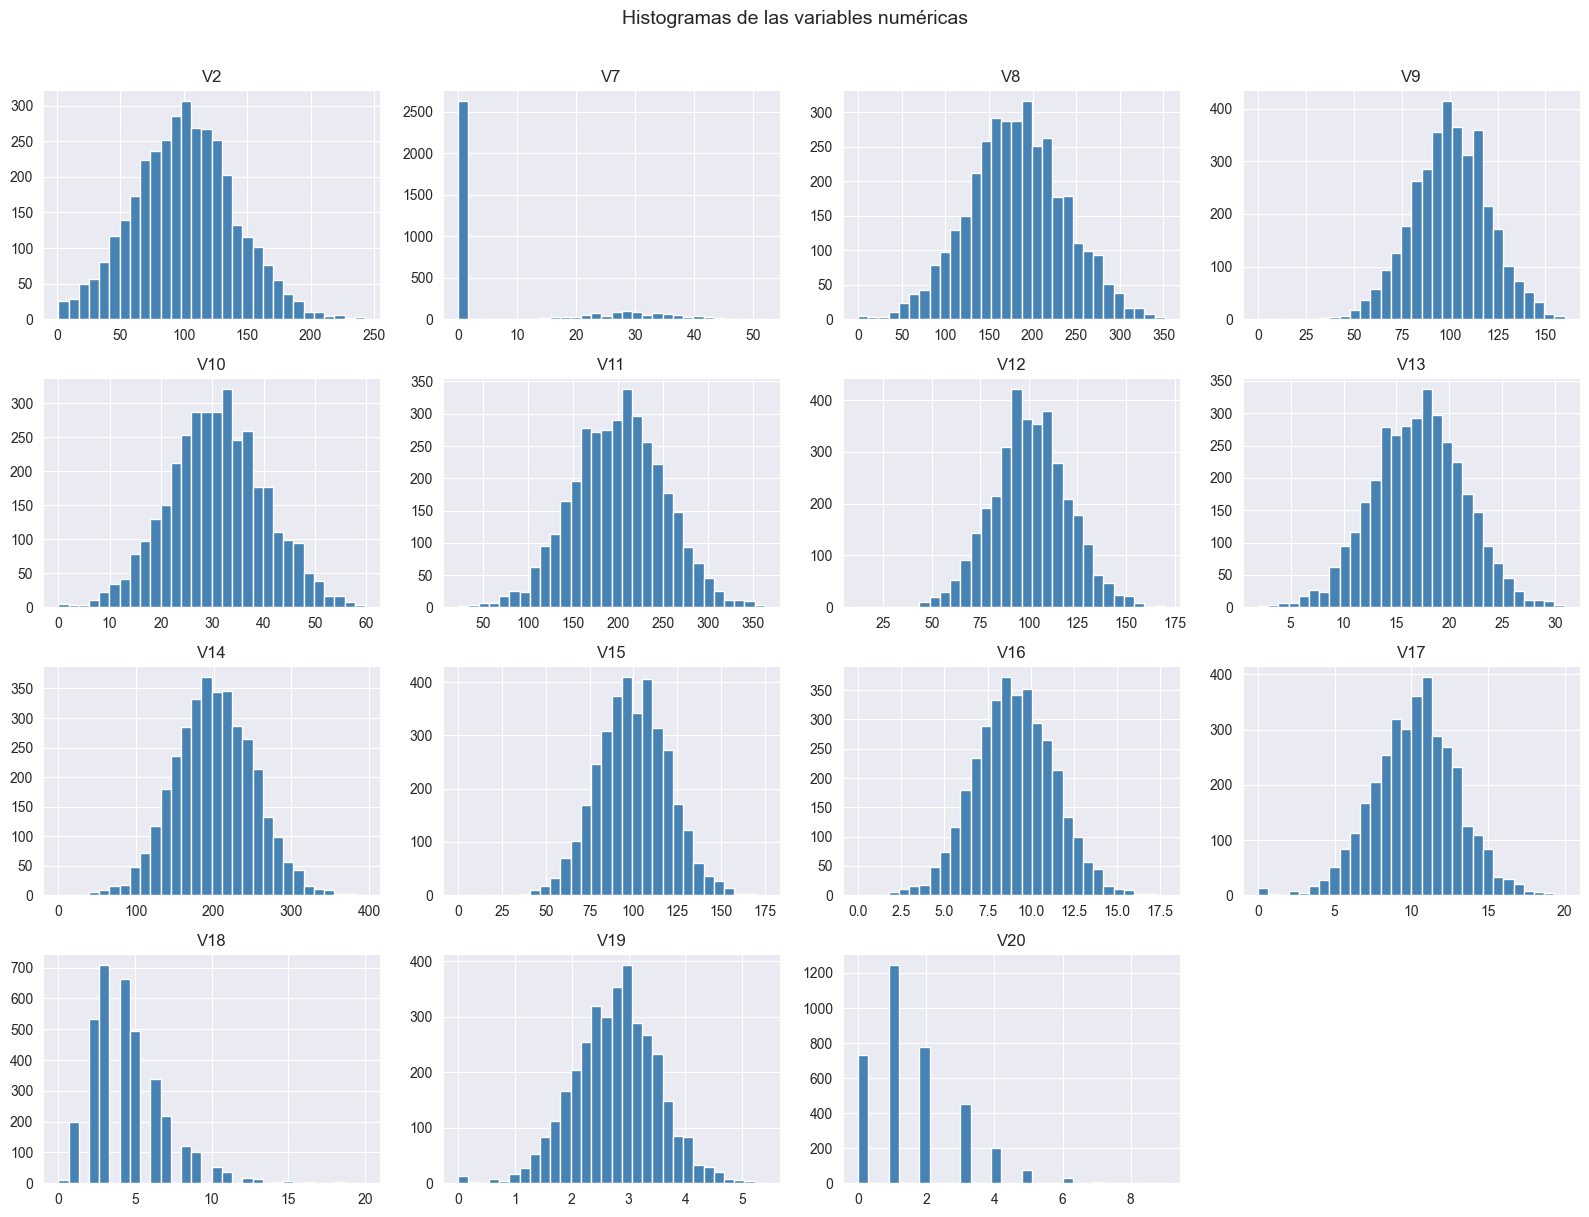

In [83]:
# Distribución de las variables numéricas: histogramas
df[var_numericas].hist(bins=30, figsize=(16, 12), color='steelblue', edgecolor='white')
plt.suptitle('Histogramas de las variables numéricas', y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

**Lectura de los descriptivos**:
- Las variables de **minutos, llamadas y costes** (V8–V16) suelen presentar distribuciones aproximadamente **normales** (asimetría ≈ 0), lo cual es favorable para SVM y muy parecidas entre ellas.
- **V7** (mensajes de buzón) presenta una gran masa en 0 (clientes sin plan de buzón, V6=no): es una distribución **bimodal/inflada en cero**. Esto no es un error, es estructural.
- **V17–V19** (internacional) y **V20** (llamadas a atención al cliente) presentan asimetría positiva y colas largas → candidatas a contener outliers.

### 1.4. Análisis de valores nulos (*missing values*)

Siguiendo la teoría: **(a)** detección, **(b)** porcentaje por variable, **(c)** patrones de ausencia y mecanismo (MCAR/MAR/MNAR), **(d)** decisión de tratamiento.

In [84]:
# (a) y (b) Detección y porcentaje por variable
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(2)
}).sort_values('pct_missing', ascending=False)
print(missing)

if missing['n_missing'].sum() == 0:
    print('\n>>> No se detectan valores nulos explícitos (NaN) en el dataset.')

     n_missing  pct_missing
V15         28         0.79
V14         26         0.73
V19         16         0.45
V10         13         0.37
V1           0         0.00
V5           0         0.00
V4           0         0.00
V3           0         0.00
V2           0         0.00
V9           0         0.00
V6           0         0.00
V8           0         0.00
V7           0         0.00
V13          0         0.00
V12          0         0.00
V11          0         0.00
V16          0         0.00
V17          0         0.00
V18          0         0.00
V20          0         0.00
Y            0         0.00


Como vemos, tras la eliminación de duplicados, no ha quedado ningún *missing*, luego comprobamos si existe alguna codificación habitual para terminar la comprobación:

In [85]:
# Los missing pueden estar codificados de forma no estándar.
# Buscamos codificaciones habituales: strings vacíos, '?', 'NA', espacios, o
# valores imposibles (negativos en variables de conteo/minutos/coste).
sospechosos = {}
for c in df.columns:
    if df[c].dtype == object:
        n = df[c].astype(str).str.strip().isin(['', '?', 'NA', 'N/A', 'na', 'null', 'None', '.']).sum()
        if n > 0:
          sospechosos[c] = f'{n} valores tipo vacío/?/NA'
for c in var_numericas:
    if pd.api.types.is_numeric_dtype(df[c]):
        n = (df[c] < 0).sum()
        if n > 0:
          sospechosos[c] = f'{n} valores negativos (imposibles)'

print('Codificaciones sospechosas de missing:', sospechosos if sospechosos else 'ninguna')

Codificaciones sospechosas de missing: ninguna


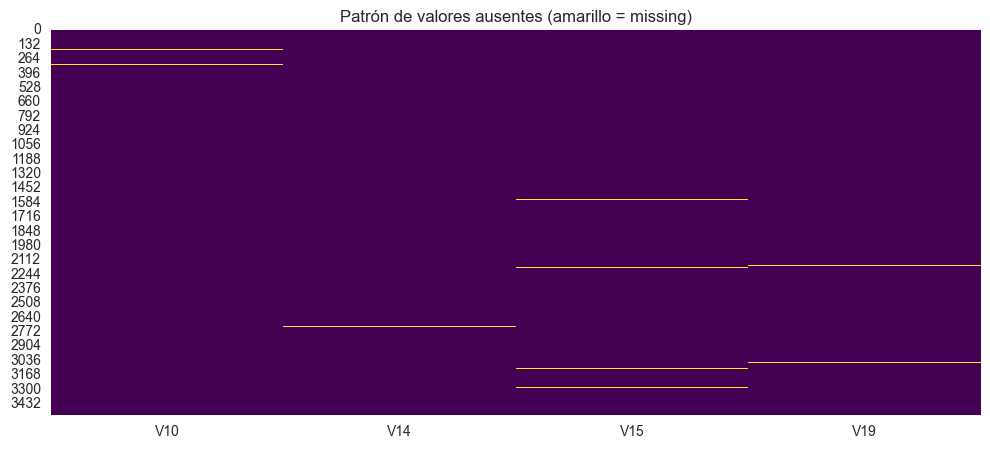

,V10,V14,V15,V19
V10,1.00,-0.01,-0.01,-0.00
V14,-0.01,1.00,-0.01,-0.01
V15,-0.01,-0.01,1.00,-0.01
V19,-0.00,-0.01,-0.01,1.00


V10: chi2 vs Y -> p-valor = 0.4468 (compatible con MCAR)
V14: chi2 vs Y -> p-valor = 0.8780 (compatible con MCAR)
V15: chi2 vs Y -> p-valor = 0.6057 (compatible con MCAR)
V19: chi2 vs Y -> p-valor = 0.8473 (compatible con MCAR)


In [86]:
# (c) Patrones de ausencia (solo si existen missing)
cols_con_na = df.columns[df.isna().any()].tolist()

if cols_con_na:
    # Visualización del patrón de ausencia
    plt.figure(figsize=(12, 5))
    sns.heatmap(df[cols_con_na].isna(), cbar=False, cmap='viridis')
    plt.title('Patrón de valores ausentes (amarillo = missing)')
    plt.show()

    # Correlación entre indicadores de ausencia (¿faltan juntas? -> patrón no aleatorio)
    if len(cols_con_na) > 1:
        display(df[cols_con_na].isna().corr().round(2))

    # Test del mecanismo: ¿la ausencia depende de la target o de otras variables?
    # Si P(missing | Y=1) != P(missing | Y=0)  ->  NO es MCAR (sería MAR o MNAR)
    for c in cols_con_na:
        ind = df[c].isna().astype(int)
        tabla = pd.crosstab(ind, df['Y'])
        chi2, p, _, _ = stats.chi2_contingency(tabla)
        print(f'{c}: chi2 vs Y -> p-valor = {p:.4f}',
              '(dependencia con Y: NO MCAR)' if p < 0.05 else '(compatible con MCAR)')
else:
    print('No hay columnas con missing: no procede el análisis de patrones.')

**Discusión del mecanismo de ausencia (MCAR / MAR / MNAR):**

- **MCAR** (*Missing Completely At Random*): la probabilidad de que falte un dato no depende ni de las variables observadas ni del propio valor ausente. Es el escenario más benigno: se puede imputar o eliminar filas sin sesgar. *Evidencia a favor*: el test chi-cuadrado del indicador de ausencia contra Y (y contra otras variables) no es significativo.
- **MAR** (*Missing At Random*): la ausencia depende de otras variables **observadas** (p. ej., faltan más mensajes de buzón V7 entre quienes no tienen plan V6). Se corrige con imputación condicionada o modelos que usen las demás variables.
- **MNAR** (*Missing Not At Random*): la ausencia depende del propio valor no observado (p. ej., clientes con facturas altísimas que ocultan su consumo). Es el peor caso; conviene crear **variables indicadoras de ausencia** para que el modelo capture esa información.

**Decisión de tratamiento (regla aplicada):**
1. Si una variable tiene **> 50% de missing** → se elimina la variable (aporta más ruido que señal).
2. Si tiene entre **5% y 50%** → imputación **+ variable indicadora** `col_missing` (0/1), por si el mecanismo fuera MAR/MNAR: así no se pierde la información de "estaba ausente".
3. Si tiene **< 5%** y el test es compatible con MCAR → imputación simple sin indicadora.
4. **Nunca** se imputa usando información del conjunto de test (se hará *fit* del imputador solo con train si aplicase dentro del pipeline).

Según el objetivo del problema, se pueden hacer distintos tipos de imputación. Si queremos un análisis descriptivo de datos o realizar un clustering, podemos imputar por la media o la mediana, ya que no perturba la distribución. Eso suele pasar con los tipos de datos MCAR.

Por otro lado, si nuestro objetivo es predecir, esta no es la mejor de las opciones puesto que estaríamos desvirtuando la distribución y estaríamos dando más peso a esos valores. Además, en casos de datos perdidos MAR y MNAR, es justo eso lo que no podemos hacer puesto que están perdidos ya que eran valores que se distinguían enormemente de esos valores medios. Luego para tratar de predecirlos, haríamos un nuevo problema donde nuestra variable objetivo sería la variable perdida y las explicativas serían el resto y haríamos una predicción de ese valor perdido.

In [88]:
# (d) Aplicación de la decisión de tratamiento
UMBRAL_ELIMINAR = 0.50
UMBRAL_INDICADORA = 0.05

for c in cols_con_na:
    pct = df[c].isna().mean()
    if pct > UMBRAL_ELIMINAR:
        df = df.drop(columns=c)
        print(f'{c}: eliminada ({pct:.1%} missing)')
    else:
        if pct >= UMBRAL_INDICADORA:
            df[c + '_missing'] = df[c].isna().astype(int)
            print(f'{c}: creada indicadora {c}_missing ({pct:.1%})')
        if pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].fillna(df[c].median())
            print(f'{c}: imputada con la MEDIANA')
        else:
            df[c] = df[c].fillna(df[c].mode()[0])
            print(f'{c}: imputada con la MODA')

print('\nMissing restantes:', df.isna().sum().sum())

V10: imputada con la MEDIANA
V14: imputada con la MEDIANA
V15: imputada con la MEDIANA
V19: imputada con la MEDIANA

Missing restantes: 0


Después del análisis realizado, como hemos detectado que las variables tenían perdidos MCAR, procedemos a imputar por la mediana. Además, las distribuciones de estas variables son bastante simétricas, por lo que es correcto imputar tanto por mediana como por media al ser estas prácticamente iguales.

### 1.5. Análisis de datos anómalos (*outliers*)

Detección **visual** (boxplots) y **estadística** (regla IQR y z-score), evaluación del impacto y decisión.

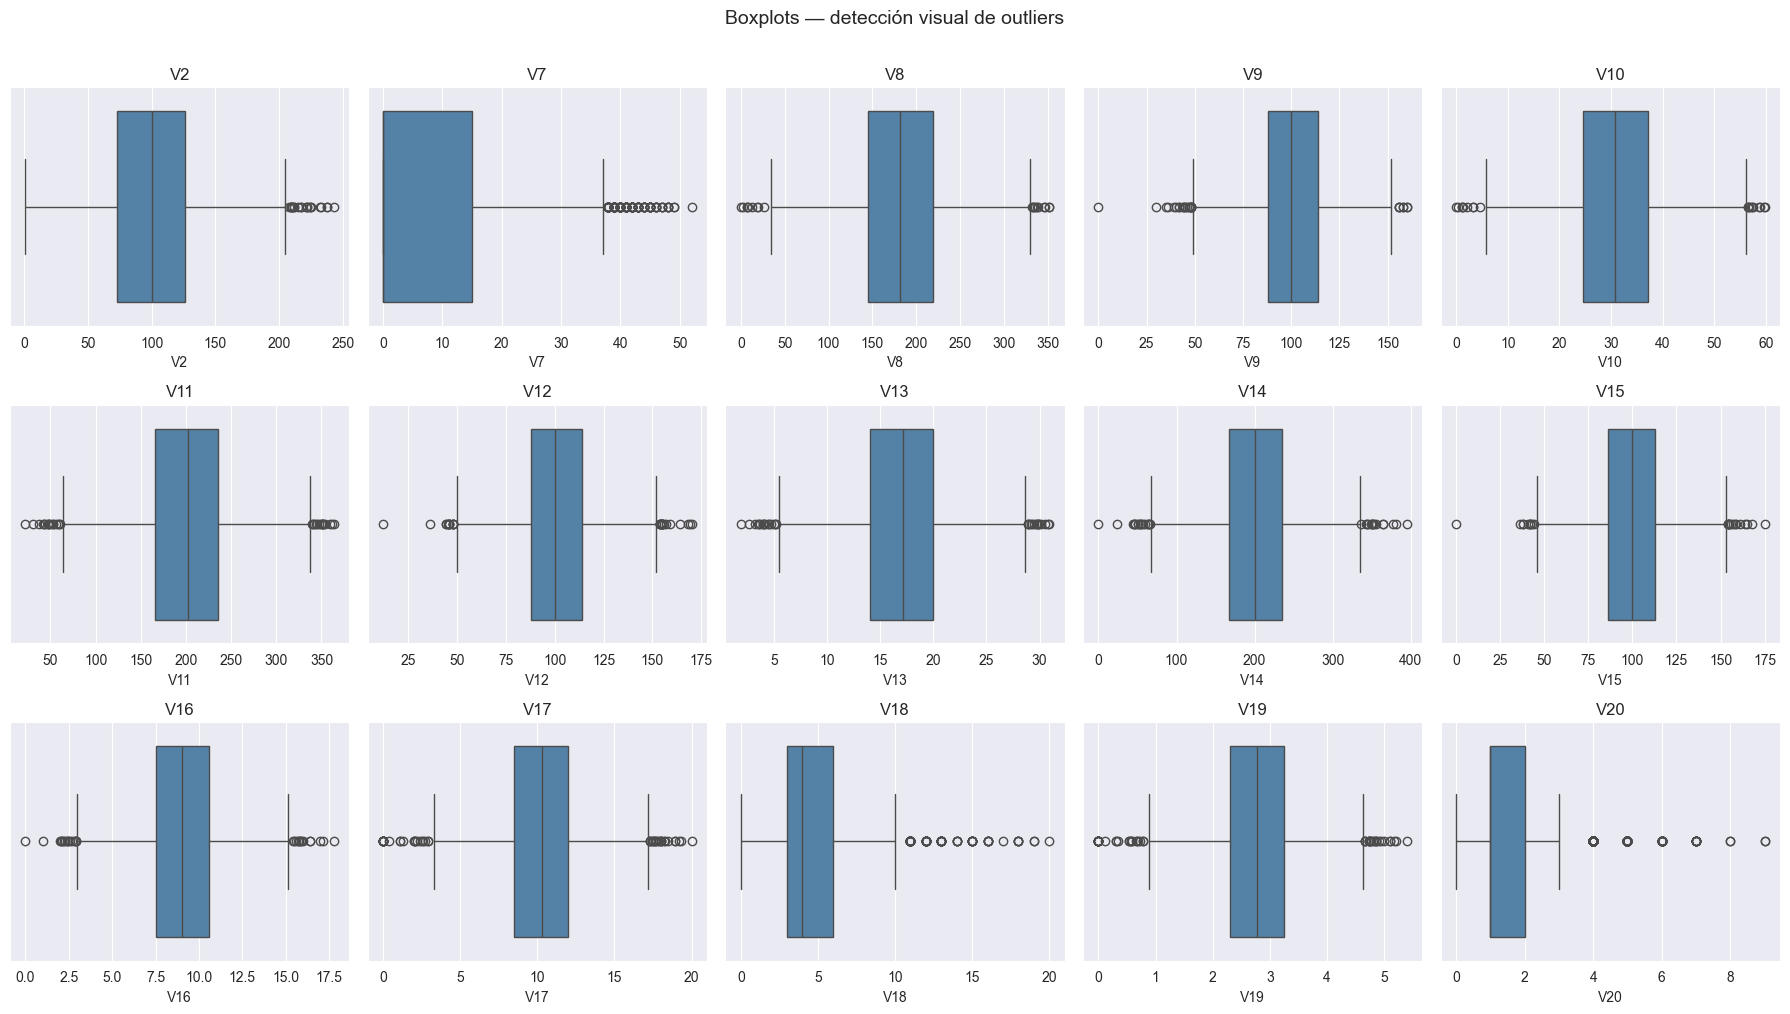

In [89]:
# Detección visual: boxplots
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, c in zip(axes.ravel(), var_numericas):
    sns.boxplot(x=df[c], ax=ax, color='steelblue')
    ax.set_title(c)
plt.suptitle('Boxplots — detección visual de outliers', y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

In [90]:
# Detección estadística: regla IQR (1.5) y z-score (|z|>3)
resumen_out = []
for c in var_numericas:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = ((df[c] < lim_inf) | (df[c] > lim_sup)).sum()
    z = np.abs(stats.zscore(df[c], nan_policy='omit'))
    n_z = (z > 3).sum()
    resumen_out.append([c, n_iqr, round(100 * n_iqr / len(df), 2), n_z,
                        round(lim_inf, 1), round(lim_sup, 1)])

pd.DataFrame(resumen_out,
             columns=['variable', 'n_outliers_IQR', '%_IQR', 'n_outliers_z>3',
                      'lim_inf', 'lim_sup'])

,variable,n_outliers_IQR,%_IQR,n_outliers_z>3,lim_inf,lim_sup
0,V2,22,0.62,11,-6.5,205.5
1,V7,150,4.24,7,-22.5,37.5
2,V8,19,0.54,8,33.1,330.0
3,V9,27,0.76,8,49.0,153.0
4,V10,19,0.54,8,5.6,56.1
5,V11,31,0.88,12,61.8,339.4
6,V12,29,0.82,6,49.0,153.0
7,V13,31,0.88,12,5.2,28.9
8,V14,32,0.90,14,66.4,335.9
9,V15,24,0.68,9,45.5,153.5


In [91]:
# Impacto de los outliers sobre media y desviación (comparación con/sin outliers z>3)
impacto = []
for c in var_numericas:   # variables con más colas
    z = np.abs(stats.zscore(df[c]))
    sin_out = df.loc[z <= 3, c]
    impacto.append([c, df[c].mean(), sin_out.mean(), df[c].std(), sin_out.std()])
pd.DataFrame(impacto, columns=['variable', 'media_con', 'media_sin',
                               'std_con', 'std_sin']).round(3)

,variable,media_con,media_sin,std_con,std_sin
0,V2,100.676,100.275,39.697,39.101
1,V7,7.587,7.506,13.454,13.341
2,V8,181.799,182.002,55.501,54.941
3,V9,100.227,100.312,19.778,19.527
4,V10,30.906,30.941,9.435,9.340
5,V11,200.772,200.958,51.026,50.244
6,V12,100.578,100.545,19.615,19.414
7,V13,17.066,17.082,4.337,4.271
8,V14,200.779,200.684,50.408,49.391
9,V15,99.677,99.664,20.000,19.711


**Diagnóstico y decisión sobre los outliers:**

Los valores extremos detectados (clientes con muchos minutos, muchas llamadas al servicio de atención, etc.) son **valores plausibles y reales del negocio**, no errores de medición: un cliente puede perfectamente llamar 9 veces a atención al cliente, y de hecho **esos casos extremos son los más informativos para predecir el churn**. Por tanto:

1. **No se eliminan** las filas: perderíamos precisamente los clientes con más riesgo (además, eliminar el ~2-5% de filas por variable acumularía una pérdida importante).
2. Solo se corregirían (imputando como missing) valores **imposibles** (negativos, minutos > 24h/día), detectados en el apartado anterior.
3. El impacto de los outliers sobre el SVM se **mitiga con la estandarización** (StandardScaler) y con el margen blando (parámetro C): el SVM con regularización adecuada es razonablemente robusto.


### 1.6. Relaciones entre variables. ¡Sobre todo con la target!

Analizamos: (a) correlaciones entre numéricas (redundancia), (b) relación de las numéricas con Y, (c) relación de las categóricas con Y.

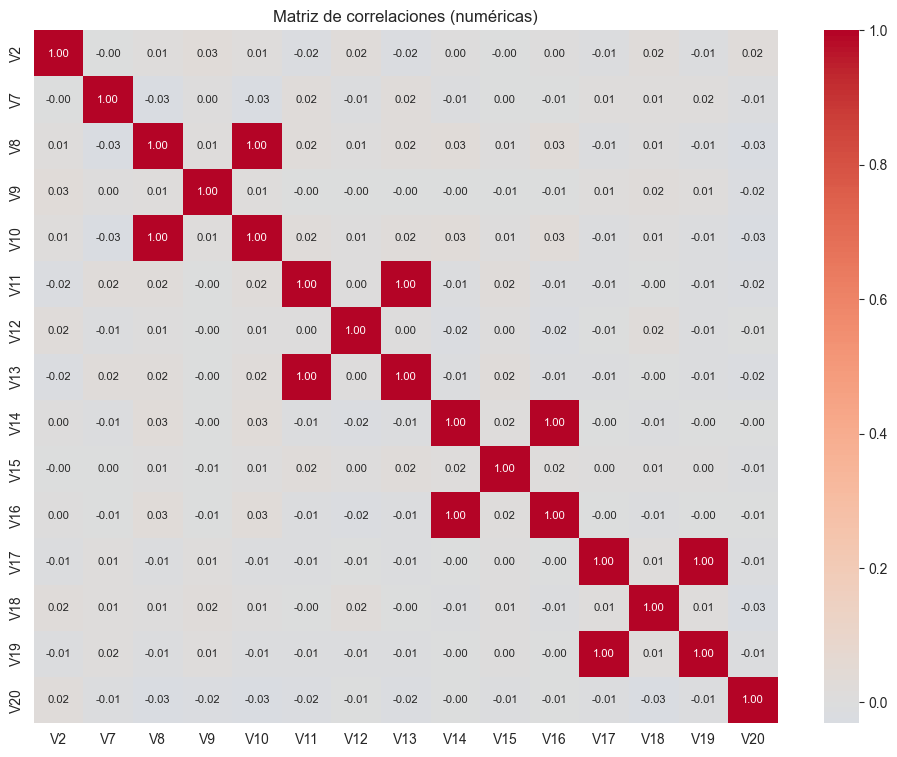

Pares con |r| > 0.95 (redundantes):
V8   V10    1.000000
V11  V13    1.000000
V17  V19    0.998763
V14  V16    0.996760
dtype: float64


In [92]:
# (a) Matriz de correlaciones entre variables numéricas
plt.figure(figsize=(12, 9))
corr = df[var_numericas].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 8})
plt.title('Matriz de correlaciones (numéricas)')
plt.show()

# Pares con correlación casi perfecta -> redundancia
pares = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(ascending=False))
print('Pares con |r| > 0.95 (redundantes):')
print(pares[abs(pares) > 0.95])

**Hallazgo clave esperado:** los pares **minutos–coste** de cada franja horaria (V8–V10, V11–V13, V14–V16, V17–V19) presentan correlación **r ≈ 1.00**, porque el coste es una función lineal determinista de los minutos (tarifa × minutos). Son variables **perfectamente redundantes**.

**Decisión (feature engineering):** eliminar una de cada par (conservamos los **minutos** y eliminamos los **costes** V10, V13, V16, V19). Justificación:
- La multicolinealidad perfecta no aporta información nueva y añade dimensiones innecesarias .
- Para el SVM lineal, reducir dimensiones redundantes mejora estabilidad e interpretabilidad; para el RBF, reduce el coste computacional.

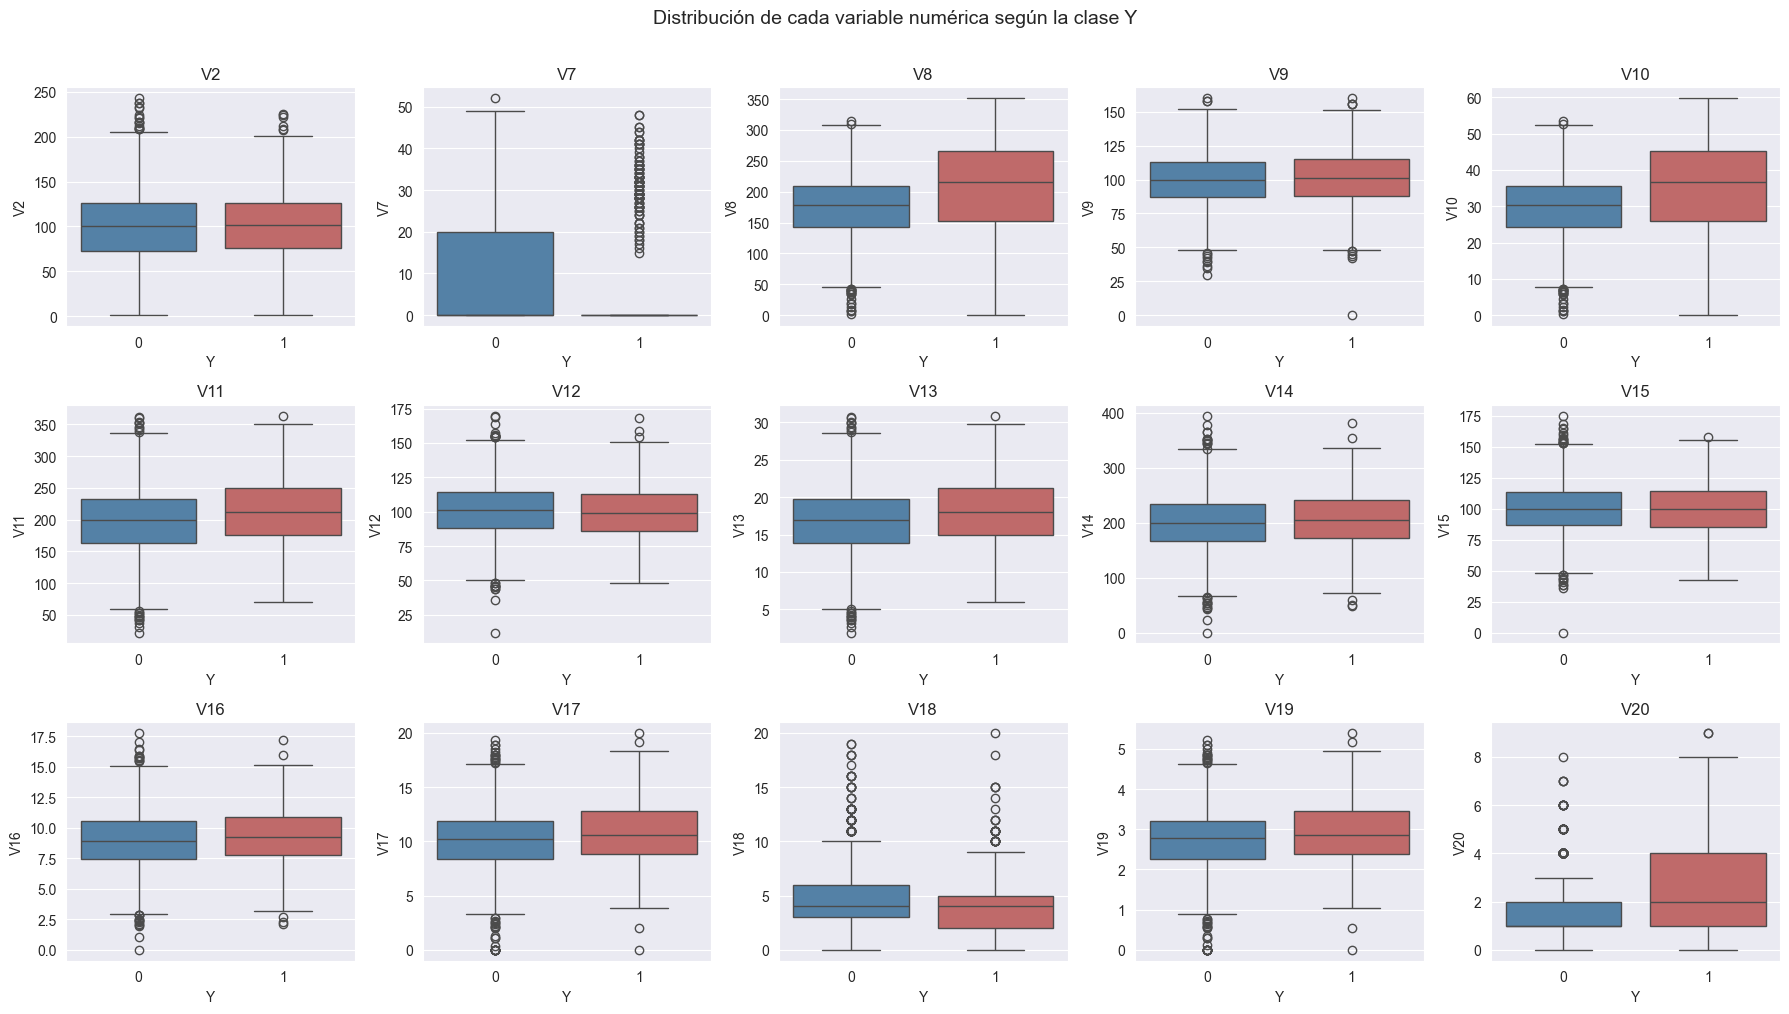

In [93]:
# (b) Relación de las numéricas con la target: boxplots por clase + test estadístico
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, c in zip(axes.ravel(), var_numericas):
    sns.boxplot(x=df['Y'], y=df[c], ax=ax, hue=df['Y'],
                palette=['steelblue', 'indianred'], legend=False)
    ax.set_title(c)
plt.suptitle('Distribución de cada variable numérica según la clase Y', y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

Ante estas distribuciones y relaciones con la variable objetivo, no conseguimos detectar ninguna variable que determine con seguridad si un cliente se va a dar de baja o no. Las dos decisiones están bastante igualadas en todas las variables, por lo que no tenemos decisión.

In [94]:
# Test de Mann-Whitney (no paramétrico, robusto a no normalidad) para cada numérica vs Y
resultados = []
for c in var_numericas:
    g0 = df.loc[df['Y'] == 0, c]
    g1 = df.loc[df['Y'] == 1, c]
    u, p = stats.mannwhitneyu(g0, g1)
    resultados.append([c, g0.mean(), g1.mean(), p])
(pd.DataFrame(resultados, columns=['variable', 'media_Y0', 'media_Y1', 'p_valor'])
   .sort_values('p_valor').round(4))

,variable,media_Y0,media_Y1,p_valor
4,V10,29.8078,35.3135,0.0000
2,V8,175.3366,207.7238,0.0000
14,V20,1.4350,2.2578,0.0000
1,V7,8.3563,4.5028,0.0000
5,V11,198.0002,211.8884,0.0000
7,V13,16.8302,18.0107,0.0000
12,V18,4.5159,4.1487,0.0000
11,V17,10.1587,10.6875,0.0000
13,V19,2.7431,2.8844,0.0000
10,V16,8.9810,9.2711,0.0028


In [95]:
# (c) Relación de las categóricas con la target: tablas + test chi-cuadrado
for c in var_cat_binaria + ['V3']:
    tabla = pd.crosstab(df[c], df['Y'], normalize='index')
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df[c], df['Y']))
    print(f'--- {c} (chi2 p-valor = {p:.4g}) ---')
    print(tabla.round(3), '\n')

# V1 (estado): tasa de churn por estado
churn_estado = df.groupby('V1')['Y'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print('Tasa de churn por estado (top 10 / bottom 5):')
print(churn_estado.head(10))
print(churn_estado.tail(5))

--- V5 (chi2 p-valor = 2.244e-60) ---
Y       0      1
V5              
0   0.839  0.161
1   0.484  0.516 

--- V6 (chi2 p-valor = 1.625e-14) ---
Y       0      1
V6              
0   0.770  0.230
1   0.888  0.112 

--- V3 (chi2 p-valor = 0.7224) ---
Y          0      1
V3                 
408.0  0.797  0.203
415.0  0.805  0.195
510.0  0.792  0.208
nan    0.857  0.143 

Tasa de churn por estado (top 10 / bottom 5):
        mean  count
V1                 
4   0.388889     36
31  0.345679     81
47  0.300000     80
26  0.291667     72
20  0.287671     73
43  0.285714     91
16  0.264706     68
33  0.261538     65
22  0.257576     66
36  0.250000     64
        mean  count
V1                 
39  0.098592     71
29  0.098361     61
0   0.098039     51
11  0.084746     59
45  0.081081     74


Al igual que pasaba con las variables numéricas, las categóricas también se distribuyen mucho por los dos valores de la variable Y, por lo que de nuevo, no existe ninguna varaible predictora que determine el abandono o no.

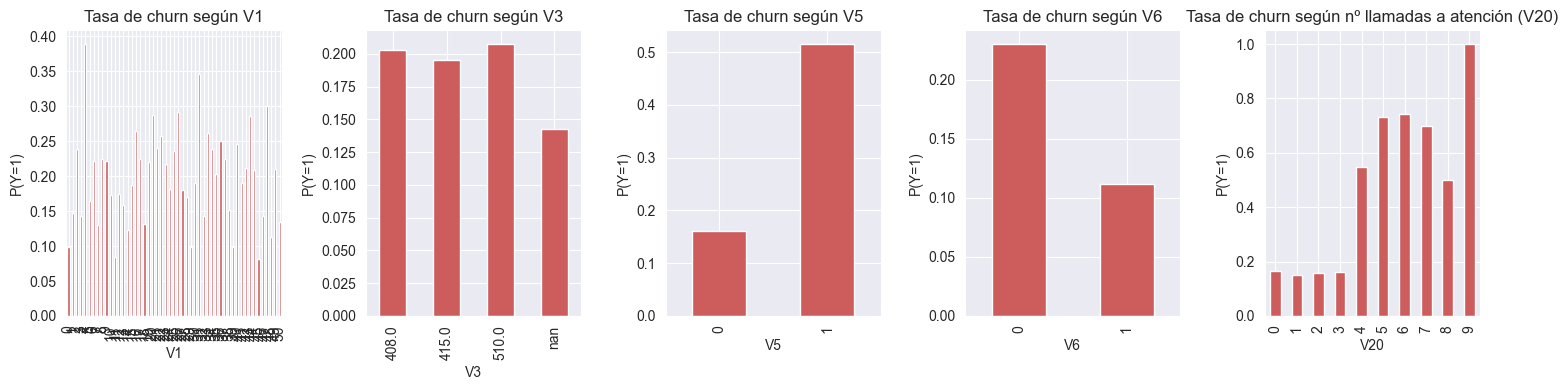

In [96]:
# Visualización: churn según los planes contratados
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, c in zip(axes, ['V1', 'V3', 'V5', 'V6', 'V20']):
    if c == 'V20':
        df.groupby(c)['Y'].mean().plot(kind='bar', ax=ax, color='indianred')
        ax.set_title('Tasa de churn según nº llamadas a atención (V20)')
    else:
        df.groupby(c)['Y'].mean().plot(kind='bar', ax=ax, color='indianred')
        ax.set_title(f'Tasa de churn según {c}')
    ax.set_ylabel('P(Y=1)')
plt.tight_layout(); plt.show()

**Conclusiones esperadas del análisis bivariante**:
- **V5 (plan internacional)**: los clientes con plan internacional presentan una tasa de churn muy superior → variable muy predictiva.
- **V20 (llamadas a atención al cliente)**: la tasa de churn se dispara a partir de 4+ llamadas → fuerte relación no lineal (argumento a favor del kernel RBF).
- **V8/V10 (uso diurno)**: los clientes que abandonan tienden a tener mayor consumo diurno.
- **V6/V7 (buzón de voz)**: efecto protector moderado (menos churn con plan de buzón).
- **V1 (estado), V3 (código de área), V2 (antigüedad)**: relación débil o nula; V4 es un identificador sin relación posible.

---
## 2. Ingeniería de variables (Feature Engineering)

Transformaciones aplicadas y su justificación específica para SVM (recordar que, según la teoría, **cada técnica exige una depuración/preparación específica**):

| Transformación | Justificación para SVM |
|---|---|
| **Eliminar V4** (nº teléfono) | Identificador único: sin capacidad de generalización, riesgo de sobreajuste. |
| **Eliminar V10, V13, V16, V19** (costes) | Correlación ≈ 1 con los minutos: redundancia perfecta. |
| **Eliminar V1** (estado) | ~51 categorías con frecuencias bajas: one-hot generaría 50 dummies dispersas (maldición de la dimensionalidad); su relación con Y es débil. Alternativa evaluada: agrupar por tasa de churn (riesgo de *leakage* si no se hace solo con train). |
| **V5, V6 → 0/1** | SVM solo admite entradas numéricas. |
| **V3 → one-hot** | Categórica nominal de baja cardinalidad (3 códigos): dummies sin problema de dimensionalidad. |
| **Ratio de intensidad V20** | Mantener V20 tal cual (ya numérica); su efecto no lineal lo capturará el kernel RBF. |
| **Estandarización (StandardScaler)** | **Imprescindible en SVM**: el algoritmo se basa en distancias/productos escalares; sin escalar, las variables de mayor magnitud (p. ej. minutos ~200) dominarían sobre las de menor (p. ej. nº llamadas ~3). Se ajusta **solo con train** (dentro de un Pipeline) para evitar fuga de información. |

In [97]:
# =====================================================
# 2. FEATURE ENGINEERING
# =====================================================
df_fe = df.copy()

# (1) Eliminar identificador
df_fe = df_fe.drop(columns=['V4'], errors='ignore')

# (2) Eliminar costes redundantes (r ~ 1 con los minutos)
df_fe = df_fe.drop(columns=['V10', 'V13', 'V16', 'V19'], errors='ignore')

# (3) Eliminar V1 (alta cardinalidad, baja señal)
df_fe = df_fe.drop(columns=['V1'], errors='ignore')

# (4) Binarias sí/no -> 1/0 (robusto a distintas codificaciones)
map_binario = {'yes': 1, 'no': 0, 'si': 1, 'sí': 1, 'y': 1, 'n': 0,
               'true': 1, 'false': 0, '1': 1, '0': 0}
for c in ['V5', 'V6']:
    df_fe[c] = (df_fe[c].astype(str).str.strip().str.lower()
                        .map(map_binario).astype(int))

# (5) One-hot para V3 (código de área)
df_fe = pd.get_dummies(df_fe, columns=['V3'], drop_first=True, dtype=int)

print(f'Dataset final: {df_fe.shape[0]} filas x {df_fe.shape[1]} columnas')
df_fe.head()

Dataset final: 3538 filas x 17 columnas


,V2,V5,V6,V7,V8,V9,V11,V12,V14,V15,V17,V18,V20,Y,V3_415.0,V3_510.0,V3_nan
0,121,0,0,0,86.1,100,259.8,113,148.0,79.0,9.1,9,2,0,1,0,0
1,170,0,0,0,184.1,106,204.9,70,224.3,133.0,9.8,3,2,0,0,1,0
2,96,0,0,0,150.0,122,218.5,116,212.4,89.0,9.8,1,3,0,0,1,0
3,90,0,0,0,193.7,83,154.2,79,299.0,60.0,12.7,3,1,0,1,0,0
4,61,0,0,0,140.6,89,172.8,128,212.4,97.0,13.6,4,1,0,1,0,0


In [98]:
# Partición train/test ESTRATIFICADA (preserva el % de churn en ambos conjuntos)
X = df_fe.drop(columns='Y')
y = df_fe['Y'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape} | churn = {y_train.mean():.3f}')
print(f'Test : {X_test.shape} | churn = {y_test.mean():.3f}')

Train: (2476, 16) | churn = 0.200
Test : (1062, 16) | churn = 0.200


Como tiene muy pocos datos, es posible que el modelo no detecte los clientes que abandonan. Posteriormente evaluaremos si es necesario un rebalanceo en el conjunto de train.

---
## 3. Modelado con Máquinas de Vector Soporte (SVM)

### 3.1. Planteamiento metodológico

Entrenamos SVM con **dos kernels**:
1. **Kernel lineal** — hipótesis: las clases son separables (aprox.) por un hiperplano en el espacio original. Hiperparámetro: **C** (regularización del margen blando: C alto = *hard margin*, menor sesgo y mayor riesgo de sobreajuste; C bajo = *soft margin*, más margen y más tolerancia al error — teoría de Cortes & Vapnik, 1995).
2. **Kernel RBF (gaussiano)** — proyecta implícitamente a un espacio de dimensión infinita (kernel trick) y permite fronteras no lineales. Hiperparámetros: **C** y **γ (gamma)** — γ alto = kernel estrecho, menor sesgo y mayor sobreajuste; γ bajo = kernel amplio y más suave. **OJO: hay interdependencia entre C y γ** (teoría), por eso se buscan conjuntamente en rejilla.

**Protocolo de búsqueda de hiperparámetros:**
- `Pipeline(StandardScaler + SVC)` → el escalado se ajusta dentro de cada fold, sin fuga de información.
- **GridSearchCV** con validación cruzada estratificada de **5 folds** sobre el train.
- **Doble métrica**: `accuracy` y `roc_auc`, como exige el enunciado. Se usa `refit='roc_auc'` como criterio principal por el desbalanceo de clases.
- Rejillas en escala **logarítmica** .
- Se prueba también `class_weight` (None vs 'balanced') por el desbalanceo.

In [99]:
# =====================================================
# 3. SVM — BÚSQUEDA DE HIPERPARÁMETROS
# =====================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc'}

# ---------- 3.2. SVM LINEAL ----------
pipe_lin = Pipeline([('scaler', StandardScaler()),
                     ('svm', SVC(kernel='linear', probability=False, random_state=SEED))])

grid_lin = {'svm__C': np.logspace(-3, 3, 13),          # 0.001 ... 1000
            'svm__class_weight': [None, 'balanced']}

gs_lin = GridSearchCV(pipe_lin, grid_lin, cv=cv, scoring=scoring,
                      refit='roc_auc', n_jobs=-1, return_train_score=True)
gs_lin.fit(X_train, y_train)

print('MEJOR SVM LINEAL')
print('Parámetros:', gs_lin.best_params_)
print(f'AUC (CV): {gs_lin.best_score_:.4f}')
idx = gs_lin.best_index_
print(f"Accuracy (CV) del mejor por AUC: {gs_lin.cv_results_['mean_test_accuracy'][idx]:.4f}")

MEJOR SVM LINEAL
Parámetros: {'svm__C': np.float64(0.31622776601683794), 'svm__class_weight': 'balanced'}
AUC (CV): 0.8184
Accuracy (CV) del mejor por AUC: 0.7601


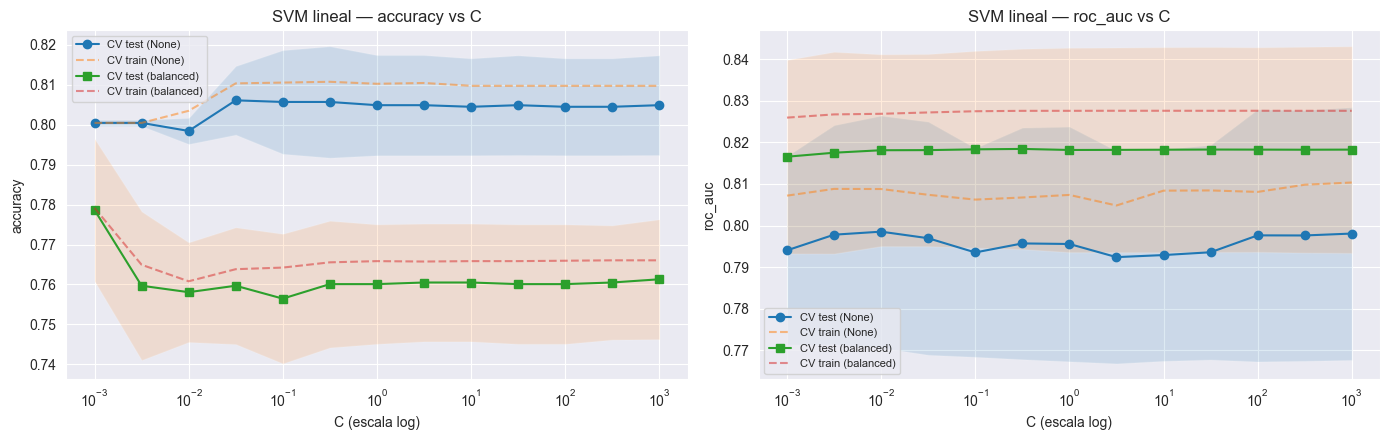

In [100]:
# Representación gráfica de la búsqueda (kernel lineal): accuracy y AUC vs C
res_lin = pd.DataFrame(gs_lin.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for metrica, ax in zip(['accuracy', 'roc_auc'], axes):
    for cw, marker in [(None, 'o'), ('balanced', 's')]:
        mask = res_lin['param_svm__class_weight'].isnull() if cw is None \
               else (res_lin['param_svm__class_weight'] == 'balanced')
        sub = res_lin[mask].sort_values('param_svm__C')
        Cs = sub['param_svm__C'].astype(float)
        ax.plot(Cs, sub[f'mean_test_{metrica}'], marker=marker,
                label=f'CV test ({cw})')
        ax.fill_between(Cs,
                        sub[f'mean_test_{metrica}'] - sub[f'std_test_{metrica}'],
                        sub[f'mean_test_{metrica}'] + sub[f'std_test_{metrica}'], alpha=0.15)
        ax.plot(Cs, sub[f'mean_train_{metrica}'], ls='--', alpha=0.5,
                label=f'CV train ({cw})')
    ax.set_xscale('log'); ax.set_xlabel('C (escala log)')
    ax.set_ylabel(metrica); ax.set_title(f'SVM lineal — {metrica} vs C')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Lectura del gráfico (kernel lineal):** la separación entre las curvas de train y test indica el grado de sobreajuste. Con C muy alto, el margen se endurece (*hard margin*) y el modelo memoriza; con C muy bajo, el modelo se vuelve trivial (infra-ajuste). El óptimo suele estar en la zona intermedia.

### 3.3. SVM con kernel RBF (búsqueda conjunta C × γ)

In [101]:
# ---------- 3.3. SVM RBF ----------
pipe_rbf = Pipeline([('scaler', StandardScaler()),
                     ('svm', SVC(kernel='rbf', random_state=SEED))])

grid_rbf = {'svm__C': np.logspace(-2, 3, 6),           # 0.01 ... 1000
            'svm__gamma': np.logspace(-4, 1, 6),        # 0.0001 ... 10
            'svm__class_weight': [None, 'balanced']}

gs_rbf = GridSearchCV(pipe_rbf, grid_rbf, cv=cv, scoring=scoring,
                      refit='roc_auc', n_jobs=-1, return_train_score=True)
gs_rbf.fit(X_train, y_train)

print('MEJOR SVM RBF')
print('Parámetros:', gs_rbf.best_params_)
print(f'AUC (CV): {gs_rbf.best_score_:.4f}')
idx = gs_rbf.best_index_
print(f"Accuracy (CV) del mejor por AUC: {gs_rbf.cv_results_['mean_test_accuracy'][idx]:.4f}")

MEJOR SVM RBF
Parámetros: {'svm__C': np.float64(100.0), 'svm__class_weight': 'balanced', 'svm__gamma': np.float64(0.01)}
AUC (CV): 0.8922
Accuracy (CV) del mejor por AUC: 0.8671


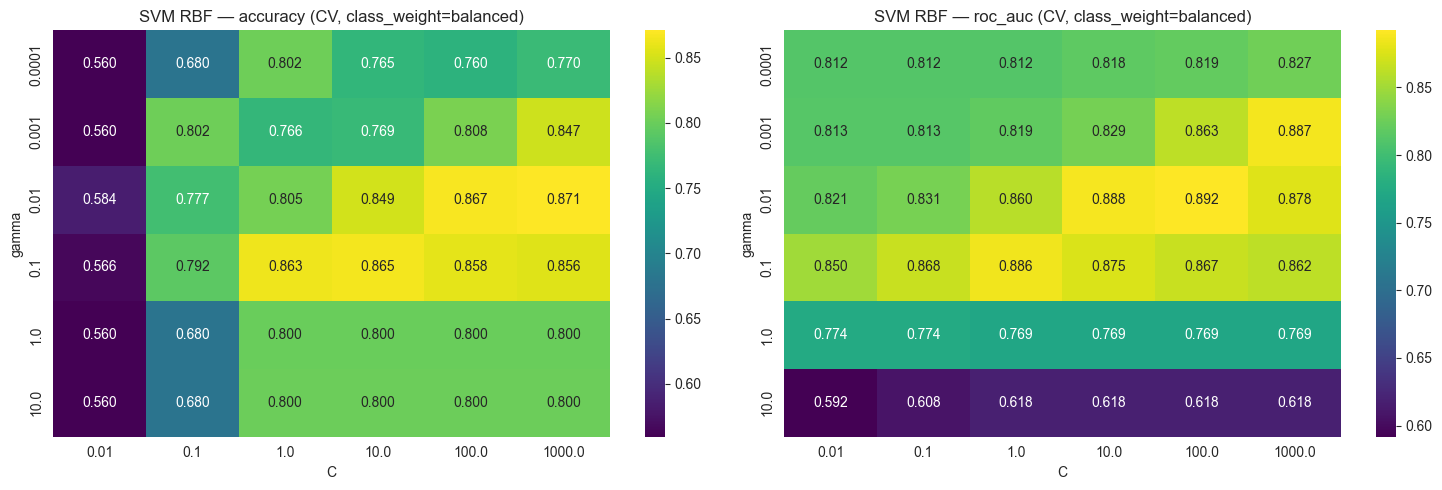

In [102]:
# Representación gráfica de la búsqueda RBF: mapas de calor C x gamma (accuracy y AUC)
res_rbf = pd.DataFrame(gs_rbf.cv_results_)
cw_best = gs_rbf.best_params_['svm__class_weight']
mask = res_rbf['param_svm__class_weight'].isnull() if cw_best is None \
       else (res_rbf['param_svm__class_weight'] == cw_best)
sub = res_rbf[mask]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for metrica, ax in zip(['accuracy', 'roc_auc'], axes):
    piv = sub.pivot_table(index='param_svm__gamma', columns='param_svm__C',
                          values=f'mean_test_{metrica}')
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='viridis', ax=ax)
    ax.set_title(f'SVM RBF — {metrica} (CV, class_weight={cw_best})')
    ax.set_xlabel('C'); ax.set_ylabel('gamma')
plt.tight_layout(); plt.show()

In [103]:
# Refinamiento de la rejilla en torno al óptimo encontrado (segunda pasada, más fina)
C_opt = gs_rbf.best_params_['svm__C']
g_opt = gs_rbf.best_params_['svm__gamma']

grid_rbf_fino = {'svm__C': np.unique(C_opt * np.logspace(-0.6, 0.6, 5)),
                 'svm__gamma': np.unique(g_opt * np.logspace(-0.6, 0.6, 5)),
                 'svm__class_weight': [gs_rbf.best_params_['svm__class_weight']]}

gs_rbf_fino = GridSearchCV(pipe_rbf, grid_rbf_fino, cv=cv, scoring=scoring,
                           refit='roc_auc', n_jobs=-1, return_train_score=True)
gs_rbf_fino.fit(X_train, y_train)

print('SVM RBF (rejilla fina)')
print('Parámetros:', gs_rbf_fino.best_params_)
print(f'AUC (CV): {gs_rbf_fino.best_score_:.4f}')
if gs_rbf_fino.best_score_ > gs_rbf.best_score_:
    gs_rbf = gs_rbf_fino
    print('>>> Se adopta el modelo de la rejilla fina.')

SVM RBF (rejilla fina)
Parámetros: {'svm__C': np.float64(50.11872336272722), 'svm__class_weight': 'balanced', 'svm__gamma': np.float64(0.01)}
AUC (CV): 0.8923
>>> Se adopta el modelo de la rejilla fina.


**Lectura de los mapas de calor (RBF):** se observa la **interdependencia C–γ** anunciada en teoría: existe una "diagonal" de buenas combinaciones (γ bajo compensado con C alto y viceversa). Valores de γ demasiado altos colapsan el rendimiento (kernel demasiado estrecho → sobreajuste extremo: cada punto es su propia isla); valores demasiado bajos aplanan el modelo hacia el comportamiento casi lineal.

### 3.4. Comparación de los dos mejores modelos y elección del ganador

La comparación se hace sobre el **conjunto de test**, con ambas métricas, matriz de confusión y curva ROC.

In [104]:
# Reentrenamos los mejores modelos con probability=True para poder trazar la ROC
mejor_lin = Pipeline([('scaler', StandardScaler()),
                      ('svm', SVC(kernel='linear', probability=True, random_state=SEED,
                                  C=gs_lin.best_params_['svm__C'],
                                  class_weight=gs_lin.best_params_['svm__class_weight']))])
mejor_lin.fit(X_train, y_train)

mejor_rbf = Pipeline([('scaler', StandardScaler()),
                      ('svm', SVC(kernel='rbf', probability=True, random_state=SEED,
                                  C=gs_rbf.best_params_['svm__C'],
                                  gamma=gs_rbf.best_params_['svm__gamma'],
                                  class_weight=gs_rbf.best_params_['svm__class_weight']))])
mejor_rbf.fit(X_train, y_train)

resultados_test = {}
for nombre, modelo in [('SVM lineal', mejor_lin), ('SVM RBF', mejor_rbf)]:
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    resultados_test[nombre] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred, 'y_prob': y_prob}
    print(f'===== {nombre} =====')
    print(f'Accuracy test: {resultados_test[nombre]["accuracy"]:.4f}')
    print(f'AUC test     : {resultados_test[nombre]["AUC"]:.4f}')
    print(classification_report(y_test, y_pred, digits=3))

===== SVM lineal =====
Accuracy test: 0.7608
AUC test     : 0.8493
              precision    recall  f1-score   support

           0      0.941     0.748     0.834       850
           1      0.446     0.811     0.575       212

    accuracy                          0.761      1062
   macro avg      0.693     0.780     0.704      1062
weighted avg      0.842     0.761     0.782      1062

===== SVM RBF =====
Accuracy test: 0.8672
AUC test     : 0.9211
              precision    recall  f1-score   support

           0      0.959     0.872     0.913       850
           1      0.623     0.849     0.719       212

    accuracy                          0.867      1062
   macro avg      0.791     0.860     0.816      1062
weighted avg      0.892     0.867     0.874      1062



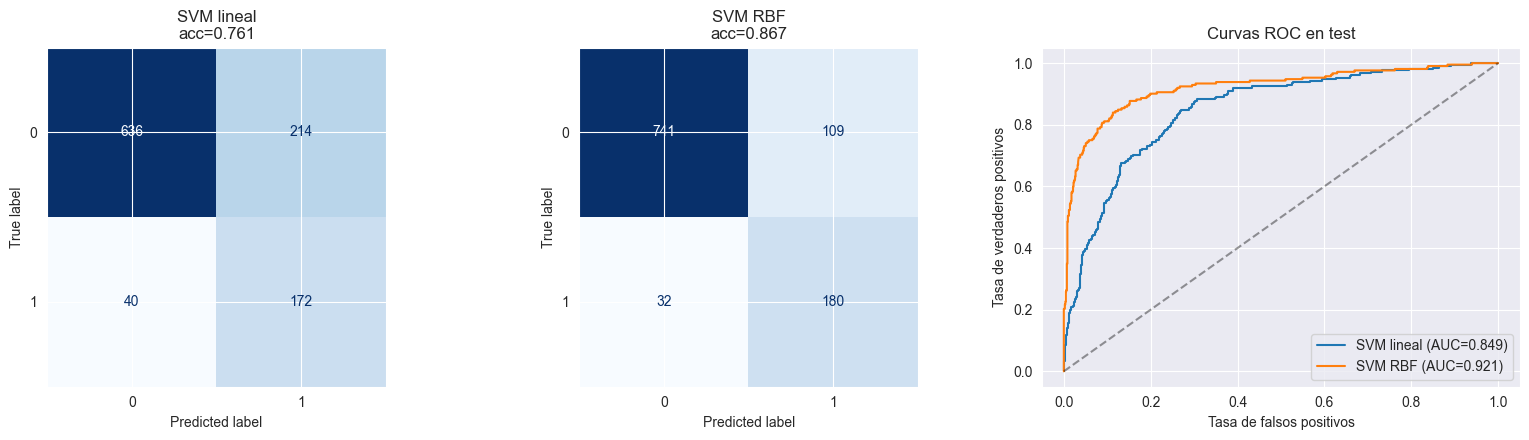

In [105]:
# Matrices de confusión y curvas ROC
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nombre, r) in zip(axes[:2], resultados_test.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, r['y_pred'])).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre}\nacc={r["accuracy"]:.3f}')

for nombre, r in resultados_test.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[2].plot(fpr, tpr, label=f'{nombre} (AUC={r["AUC"]:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_xlabel('Tasa de falsos positivos'); axes[2].set_ylabel('Tasa de verdaderos positivos')
axes[2].set_title('Curvas ROC en test'); axes[2].legend()
plt.tight_layout(); plt.show()

In [106]:
# Tabla resumen comparativa
tabla = pd.DataFrame({
    'Modelo': ['SVM lineal', 'SVM RBF'],
    'Mejores hiperparámetros': [str(gs_lin.best_params_), str(gs_rbf.best_params_)],
    'AUC (CV 5-fold)': [gs_lin.best_score_, gs_rbf.best_score_],
    'Accuracy test': [resultados_test['SVM lineal']['accuracy'],
                      resultados_test['SVM RBF']['accuracy']],
    'AUC test': [resultados_test['SVM lineal']['AUC'],
                 resultados_test['SVM RBF']['AUC']]
}).round(4)
tabla

,Modelo,Mejores hiperparámetros,AUC (CV 5-fold),Accuracy test,AUC test
0,SVM lineal,"{'svm__C': np.float64(0.31622776601683794), 's...",0.8184,0.7608,0.8493
1,SVM RBF,"{'svm__C': np.float64(50.11872336272722), 'svm...",0.8923,0.8672,0.9211


### 3.5. Elección razonada del modelo ganador

**Criterios de decisión**:

1. **Rendimiento predictivo**: en este problema es esperable que el **SVM RBF supere al lineal** tanto en accuracy como en AUC. La razón es sustantiva, no solo numérica: el EDA reveló relaciones **no lineales** con la target. Un hiperplano en el espacio original no puede capturar estos umbrales e interacciones; el kernel RBF, al mapear implícitamente a un espacio de dimensión infinita, sí.
2. **Consistencia CV–test**: el modelo ganador debe mostrar un rendimiento en test coherente con el de la validación cruzada (diferencia pequeña → buen equilibrio sesgo-varianza, sin sobreajuste de la selección de hiperparámetros).
3. **Coste de los errores**: en churn, un falso negativo (cliente que se va sin ser detectado) suele costar más que un falso positivo (campaña de retención innecesaria). Se debe examinar el *recall* de la clase 1 en la matriz de confusión; si el RBF gana también en recall, la decisión se refuerza.
4. **Contrapartida asumida**: el kernel lineal es más explicable y más barato computacionalmente. Para un caso de uso de *churn/marketing* la teoría del módulo admite explícitamente el balance precisión–riesgo, por lo que **se elige el SVM RBF como modelo ganador**, y será el modelo base sobre el que se construirá el bagging del apartado 3 del trabajo.

In [107]:
# Modelo ganador final (se conservará para el apartado de ensamblado)
ganador = 'SVM RBF' if resultados_test['SVM RBF']['AUC'] >= resultados_test['SVM lineal']['AUC'] else 'SVM lineal'
modelo_ganador = mejor_rbf if ganador == 'SVM RBF' else mejor_lin
print(f'>>> MODELO GANADOR: {ganador}')
print(f'    AUC test = {resultados_test[ganador]["AUC"]:.4f} | '
      f'Accuracy test = {resultados_test[ganador]["accuracy"]:.4f}')

# Guardado opcional para reutilizarlo en el apartado de Bagging/Stacking
import joblib
joblib.dump(modelo_ganador, 'svm_ganador.joblib')
print('Modelo guardado en svm_ganador.joblib')

>>> MODELO GANADOR: SVM RBF
    AUC test = 0.9211 | Accuracy test = 0.8672
Modelo guardado en svm_ganador.joblib


---
## 4. Ensamblado: Bagging y Stacking (Cuestión 3)

En esta sección aplicamos **métodos de ensemble**. Según la teoría del módulo:

> *"Los métodos de Ensemble ('métodos combinados') utilizan múltiples algoritmos de aprendizaje para obtener un rendimiento predictivo que mejore el que podría obtenerse por medio de cualquiera de los algoritmos de aprendizaje individuales que lo constituyen."*

Es decir, en lugar de depender de un único modelo, se **combinan varios modelos** para obtener un resultado más **robusto y preciso**. Los dos esquemas que exige el enunciado y que desarrollamos son:

1. **Bagging** (*Bootstrap Aggregating*) sobre el **mejor modelo individual** del apartado anterior (el SVM ganador).
2. **Stacking**, combinando varios clasificadores base de familias distintas mediante un **meta-modelo**.

**Depuración/preparación de datos necesaria para esta técnica.** Los métodos de ensamblado heredan los requisitos de sus modelos base. Como nuestros modelos base incluyen SVM, KNN y regresión logística (todos basados en distancias o productos escalares), **reutilizamos exactamente la misma matriz de datos depurada del apartado 2** (`X_train`, `X_test`): sin identificadores (V4), sin costes redundantes (V10, V13, V16, V19), sin V1, binarias mapeadas a 0/1, one-hot de V3 y **estandarización dentro de cada Pipeline** (se ajusta el scaler solo con los datos de cada fold/muestra bootstrap, evitando fugas de información). Los modelos de árbol (Random Forest) no necesitan escalado, pero no les perjudica, por lo que una única preparación es válida para todos los miembros del ensemble. Este punto es importante porque, como vimos en teoría, al combinar modelos de familias distintas hay que vigilar las **escalas de las predicciones**: por ello combinaremos siempre **probabilidades** (todas en [0,1]) y no salidas de distinta naturaleza.

### 4.1. Bagging sobre el mejor modelo individual (SVM RBF)

**¿En qué consiste el bagging?** La **agregación Bootstrap (Bagging)** es un meta-algoritmo que construye combinaciones de modelos a partir de una familia inicial, provocando una **disminución de la varianza** y **evitando el sobreajuste** (teoría del módulo). El proceso, para construir *B* modelos:

1. **Extracción de muestras bootstrap** de los datos de entrenamiento (muestreo con reemplazamiento).
2. **Construcción de un modelo individual** para cada muestra bootstrap.
3. **Predicción en test** con cada uno de los modelos.
4. **Promedio/agregación** de las predicciones individuales (promedio de probabilidades / voto mayoritario en clasificación).

**¿Cuál es su objetivo en este problema?** Nuestro modelo ganador es un **SVM RBF**, un modelo flexible (bajo sesgo) cuyo riesgo es la **varianza**: la frontera de decisión puede depender de los puntos concretos (vectores soporte) de la muestra de entrenamiento. Al entrenar muchos SVM sobre remuestreos distintos y **promediar sus probabilidades**, las fluctuaciones individuales se compensan y obtenemos una frontera más **estable y generalizable**. En términos de la justificación teórica vista en clase (Tumer & Ghosh, 1996), agregamos clasificadores de **sesgo similar** (todos son el mismo SVM óptimo) y correlación < 1 (cada uno ve datos distintos), por lo que el término de varianza del error se reduce en un factor `(1 + δ(N-1))/N` sin apenas tocar el sesgo.

**Decisiones de diseño (justificación):**

| Decisión | Valor | Justificación |
|---|---|---|
| Estimador base | Pipeline `StandardScaler + SVC(RBF)` con los **hiperparámetros ganadores** del apartado 3 | El enunciado pide bagging "sobre el mejor modelo individual". Al meter el scaler dentro del estimador base, cada muestra bootstrap se estandariza con sus propios estadísticos (sin leakage). |
| `probability=True` | — | Necesario para que el bagging **promedie probabilidades** (agregación *soft*, más fina que el voto) y para poder calcular el **AUC**. |
| `max_samples` | rejilla {0.5, 0.7, 1.0} | Es el % de la muestra que extraemos en cada bootstrap (mismo papel que en el código de clase). Submuestrear (<1) aumenta la **diversidad** entre modelos base, que es la fortaleza del bagging según la teoría. |
| `n_estimators` | rejilla {10, 25, 50} | Como en el código de clase, exploramos cómo evoluciona el rendimiento con el nº de clasificadores. En bagging, más estimadores **nunca sobreajustan** (solo estabilizan), pero el coste computacional con SVM crece linealmente: buscamos el punto de estabilización. |
| `max_features=1.0`, `bootstrap_features=False` | — | Bagging clásico: tras el feature engineering solo quedan ~13 variables ya poco redundantes; sortear variables (estilo Random Subspaces) eliminaría predictores clave como V5 o V20 en muchos miembros. La diversidad la aportamos vía muestras, no vía variables. |
| Selección de la mejor combinación | **Validación cruzada** (no el test) | Elegir hiperparámetros mirando el test sería *leakage* de selección. Usamos CV estratificada sobre train con doble métrica (accuracy y AUC), coherente con el protocolo del apartado 3. |


In [108]:
# =====================================================
# 4.1 BAGGING sobre el SVM ganador
# =====================================================
from sklearn.ensemble import BaggingClassifier
from sklearn.base import clone
import time

# Estimador base: el MEJOR modelo individual del apartado 3 (SVM RBF ganador),
# reconstruido con probability=True para poder promediar probabilidades y calcular AUC.
params_ganador = {k.replace('svm__', ''): v
                  for k, v in gs_rbf.best_params_.items()}
print('Hiperparámetros del SVM ganador que usaremos como base:', params_ganador)

base_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=SEED, **params_ganador))
])

# Recordatorio del rendimiento del modelo individual (referencia a batir/estabilizar)
print(f"\nReferencia SVM RBF individual -> Accuracy test: "
      f"{resultados_test['SVM RBF']['accuracy']:.4f} | AUC test: {resultados_test['SVM RBF']['AUC']:.4f}")

Hiperparámetros del SVM ganador que usaremos como base: {'C': np.float64(50.11872336272722), 'class_weight': 'balanced', 'gamma': np.float64(0.01)}

Referencia SVM RBF individual -> Accuracy test: 0.8672 | AUC test: 0.9211


In [109]:
# Exploración del efecto de n_estimators y max_samples 
from sklearn.model_selection import cross_validate

# Cada miembro del bagging es un SVM completo con probability=True
# (que internamente hace otra CV para calibrar probabilidades). Por eso limitamos la
# rejilla a n_estimators <= 50: como se vera en las curvas, el rendimiento se estabiliza
# mucho antes y anadir mas estimadores solo aporta coste (en bagging nunca sobreajusta).
lista_max_samples = [0.5, 0.7, 1.0]   # % de la muestra en cada bootstrap
lista_n_estimators = [10, 25, 50]     # nº de clasificadores agregados

cv_bag = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
resultados_bagging = []

print('Evaluando el impacto del nº de clasificadores y el tamaño de muestra (CV en train):')
for ms in lista_max_samples:
    print(f'\n--- max_samples = {ms} ---')
    for n in lista_n_estimators:
        bag = BaggingClassifier(estimator=clone(base_svm),
                                n_estimators=n,
                                max_samples=ms,
                                max_features=1.0,
                                bootstrap=True,
                                bootstrap_features=False,
                                random_state=SEED,
                                n_jobs=-1)
        t0 = time.time()
        cv_res = cross_validate(bag, X_train, y_train, cv=cv_bag,
                                scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
                                n_jobs=-1)
        acc = cv_res['test_accuracy'].mean()
        auc = cv_res['test_roc_auc'].mean()
        resultados_bagging.append([ms, n, acc, auc])
        print(f'  n_estimators={n:>3} | Accuracy CV: {acc:.4f} | AUC CV: {auc:.4f} '
              f'| ({time.time()-t0:.1f}s)')

res_bag = pd.DataFrame(resultados_bagging,
                       columns=['max_samples', 'n_estimators', 'accuracy_cv', 'auc_cv'])

Evaluando el impacto del nº de clasificadores y el tamaño de muestra (CV en train):

--- max_samples = 0.5 ---
  n_estimators= 10 | Accuracy CV: 0.8784 | AUC CV: 0.8829 | (2.7s)
  n_estimators= 25 | Accuracy CV: 0.8728 | AUC CV: 0.8843 | (5.3s)
  n_estimators= 50 | Accuracy CV: 0.8760 | AUC CV: 0.8857 | (9.2s)

--- max_samples = 0.7 ---
  n_estimators= 10 | Accuracy CV: 0.8833 | AUC CV: 0.8856 | (3.0s)
  n_estimators= 25 | Accuracy CV: 0.8792 | AUC CV: 0.8862 | (6.8s)
  n_estimators= 50 | Accuracy CV: 0.8772 | AUC CV: 0.8862 | (13.1s)

--- max_samples = 1.0 ---
  n_estimators= 10 | Accuracy CV: 0.8833 | AUC CV: 0.8856 | (5.2s)
  n_estimators= 25 | Accuracy CV: 0.8829 | AUC CV: 0.8853 | (11.6s)
  n_estimators= 50 | Accuracy CV: 0.8797 | AUC CV: 0.8866 | (24.9s)


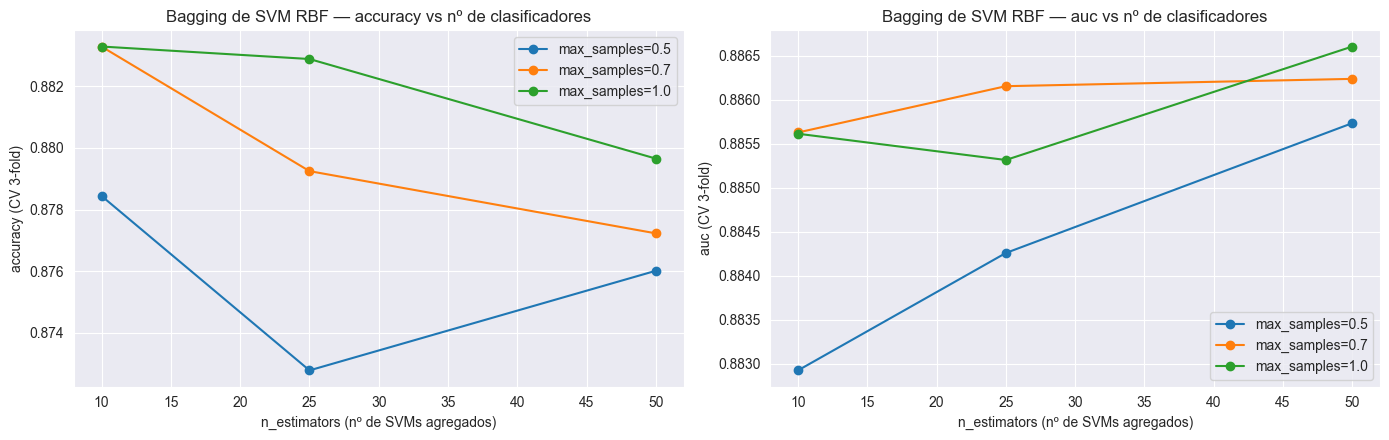

In [110]:
# Representación gráfica de la búsqueda (accuracy y AUC, como exige el protocolo)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for metrica, ax in zip(['accuracy_cv', 'auc_cv'], axes):
    for ms in lista_max_samples:
        sub = res_bag[res_bag['max_samples'] == ms]
        ax.plot(sub['n_estimators'], sub[metrica], marker='o', label=f'max_samples={ms}')
    ax.set_xlabel('n_estimators (nº de SVMs agregados)')
    ax.set_ylabel(metrica.replace('_cv', '') + ' (CV 3-fold)')
    ax.set_title(f'Bagging de SVM RBF — {metrica.replace("_cv","")} vs nº de clasificadores')
    ax.legend()
plt.tight_layout(); plt.show()

In [111]:
# Selección de la mejor configuración por AUC de CV y evaluación FINAL sobre test
mejor_cfg = res_bag.loc[res_bag['auc_cv'].idxmax()]
print('Mejor configuración por AUC (CV):')
print(mejor_cfg, '\n')

bagging_final = BaggingClassifier(estimator=clone(base_svm),
                                  n_estimators=int(mejor_cfg['n_estimators']),
                                  max_samples=float(mejor_cfg['max_samples']),
                                  max_features=1.0,
                                  bootstrap=True,
                                  bootstrap_features=False,
                                  random_state=SEED,
                                  n_jobs=-1)
bagging_final.fit(X_train, y_train)

y_pred_bag  = bagging_final.predict(X_test)
y_prob_bag  = bagging_final.predict_proba(X_test)[:, 1]

acc_bag_test  = accuracy_score(y_test, y_pred_bag)
auc_bag_test  = roc_auc_score(y_test, y_prob_bag)
acc_bag_train = bagging_final.score(X_train, y_train)

print('===== BAGGING (SVM RBF) — evaluación en test =====')
print(f'Accuracy train: {acc_bag_train:.4f}')
print(f'Accuracy test : {acc_bag_test:.4f}')
print(f'AUC test      : {auc_bag_test:.4f}')
print()
print(classification_report(y_test, y_pred_bag, digits=3))

# Guardamos los resultados para la comparación global (apartado 5)
resultados_test['Bagging (SVM RBF)'] = {'accuracy': acc_bag_test, 'AUC': auc_bag_test,
                                        'y_pred': y_pred_bag, 'y_prob': y_prob_bag}

Mejor configuración por AUC (CV):
max_samples      1.000000
n_estimators    50.000000
accuracy_cv      0.879650
auc_cv           0.886605
Name: 8, dtype: float64 

===== BAGGING (SVM RBF) — evaluación en test =====
Accuracy train: 0.9245
Accuracy test : 0.9096
AUC test      : 0.9228

              precision    recall  f1-score   support

           0      0.922     0.969     0.945       850
           1      0.845     0.670     0.747       212

    accuracy                          0.910      1062
   macro avg      0.883     0.820     0.846      1062
weighted avg      0.906     0.910     0.906      1062



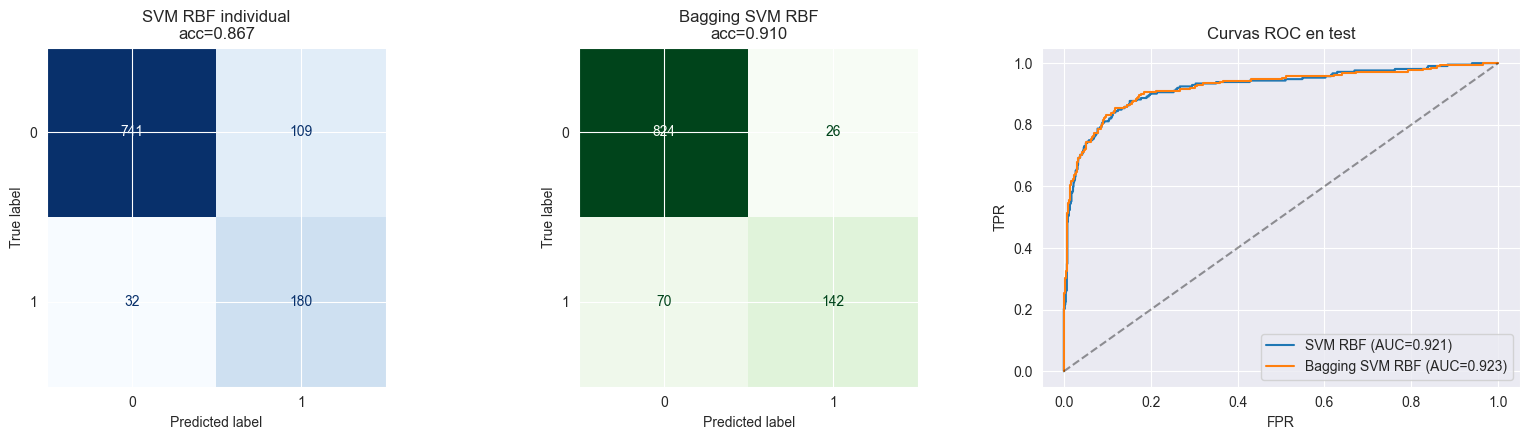

Gap de sobreajuste (accuracy train - accuracy test):
  SVM RBF individual: +0.0265
  Bagging SVM RBF   : +0.0149


In [112]:
# Comparación directa individual vs bagging: matriz de confusión y ROC,
# y análisis del gap train-test (la reducción de varianza es el objetivo del bagging)
y_pred_svm  = resultados_test['SVM RBF']['y_pred']
y_prob_svm  = resultados_test['SVM RBF']['y_prob']
acc_svm_train = mejor_rbf.score(X_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm)).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'SVM RBF individual\nacc={resultados_test["SVM RBF"]["accuracy"]:.3f}')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_bag)).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Bagging SVM RBF\nacc={acc_bag_test:.3f}')

for nombre, prob in [('SVM RBF', y_prob_svm), ('Bagging SVM RBF', y_prob_bag)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[2].plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_score(y_test, prob):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('Curvas ROC en test'); axes[2].legend()
plt.tight_layout(); plt.show()

print('Gap de sobreajuste (accuracy train - accuracy test):')
print(f'  SVM RBF individual: {acc_svm_train - resultados_test["SVM RBF"]["accuracy"]:+.4f}')
print(f'  Bagging SVM RBF   : {acc_bag_train - acc_bag_test:+.4f}')

### 4.2. Stacking

**¿En qué consiste?** El stacking va un paso más allá del bagging: combina las predicciones de **diferentes modelos base** (de familias distintas), pero en lugar de usar una combinación simple (promedio o voto), emplea un **modelo adicional, el "meta-modelo"**, que **aprende** cuál es la mejor forma de ponderar/combinar dichas predicciones:

1. Selección de modelos base (idealmente, *"cubrir las necesidades de unos con las fortalezas de otros"*).
2–3. División train/test y entrenamiento de los modelos base con train.
4–5. Generación de predicciones de los modelos base y construcción del **conjunto de datos meta** (las predicciones como características).
6. Entrenamiento del **meta-modelo** sobre los datos meta.
7. Predicción final sobre datos nuevos.

**Implementación:** usamos `StackingClassifier` de sklearn (como en el código de clase), que automatiza los pasos 4–6 con un detalle metodológico crucial: las predicciones-características se generan mediante **validación cruzada interna** (`cv=5`), de forma que el meta-modelo se entrena con predicciones *out-of-fold*, nunca con predicciones sobre datos que el modelo base ya vio. Recordamos de la teoría lo siguiente: *"el conjunto de datos meta se utiliza solo durante el entrenamiento del meta-modelo y no debe confundirse con el conjunto de prueba original"*, y evita que el meta-modelo aprenda del sobreajuste de los modelos base.

**Selección y configuración de los clasificadores base.** Según la teoría, conviene unir clasificadores con **sesgo bajo y similar** y **poca correlación** entre ellos (fronteras de decisión de naturaleza distinta):

| Clasificador base | Familia / frontera | Por qué lo incluimos | Configuración |
|---|---|---|---|
| **SVM RBF** (ganador ap. 3) | Kernel / frontera no lineal suave | Es nuestro mejor modelo individual; aporta la señal principal. | Pipeline scaler+SVC con los hiperparámetros óptimos del grid search, `probability=True`. |
| **Random Forest** | Ensemble de árboles / fronteras por umbrales ortogonales | Captura umbrales e interacciones (p. ej. "V20 ≥ 4") de forma distinta al SVM; muy poco correlacionado con métodos de kernel (era la pareja recomendada en el caso real de clase: *"las redes/kernel combinarán bien con GBM o Random Forest"*). No necesita escalado. | 500 árboles, `random_state=SEED`. |
| **Regresión logística** | Lineal / hiperplano | Modelo de **sesgo alto pero varianza mínima**; aporta la componente lineal "limpia" y estabiliza el ensemble. | Pipeline scaler+LogisticRegression. |
| **KNN** | Local / basado en distancias | Frontera puramente local, filosofía radicalmente distinta a las tres anteriores → añade diversidad (baja correlación). | Pipeline scaler+KNN (k=15, k moderado para suavizar la varianza local). |

**Meta-modelo: regresión logística.** Es la elección estándar y la más defendible: (i) el conjunto meta tiene solo 4 características (las probabilidades de los base), un problema pequeño donde un meta-modelo complejo sobreajustaría — la teoría advierte de las *"excesivas posibilidades que a veces llevan al sobreajuste"*; (ii) sus **coeficientes son interpretables como pesos** de cada clasificador base (equivale a un promediado ponderado aprendido, la opción 3 "estrictamente stacking" de los apuntes); (iii) al combinar **probabilidades** (`stack_method='predict_proba'`), todas las entradas del meta-modelo están en la misma escala [0,1], atendiendo al aviso de la teoría sobre las escalas al mezclar familias.

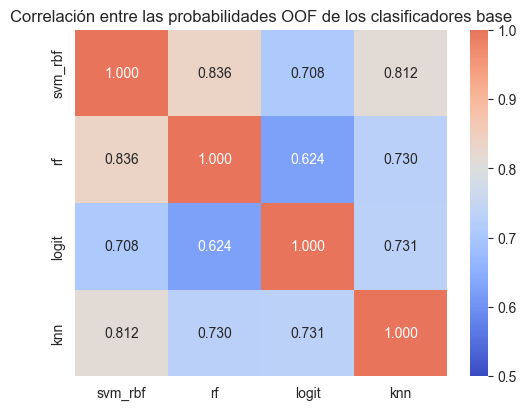

AUC individual (out-of-fold, train) de cada clasificador base:
  svm_rbf : 0.8918
  rf      : 0.9068
  logit   : 0.8104
  knn     : 0.8496


In [113]:
# =====================================================
# 4.2 STACKING
# =====================================================
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Clasificadores base (cada uno con SU preparación: scaler dentro del pipeline
#     para los basados en distancias; el RF no lo necesita) ---
base_svm_stack = Pipeline([('scaler', StandardScaler()),
                           ('svm', SVC(kernel='rbf', probability=True,
                                       random_state=SEED, **params_ganador))])

base_rf    = RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)

base_logit = Pipeline([('scaler', StandardScaler()),
                       ('logit', LogisticRegression(max_iter=2000, random_state=SEED))])

base_knn   = Pipeline([('scaler', StandardScaler()),
                       ('knn', KNeighborsClassifier(n_neighbors=15))])

clasificadores_base = [('svm_rbf', base_svm_stack),
                       ('rf', base_rf),
                       ('logit', base_logit),
                       ('knn', base_knn)]

# Antes de apilar, verificamos la premisa teórica: DIVERSIDAD (baja correlación
# entre las predicciones de los modelos base). Usamos predicciones out-of-fold
# sobre train (cross_val_predict) para no hacernos trampas.
probs_oof = {}
for nombre, modelo in clasificadores_base:
    probs_oof[nombre] = cross_val_predict(modelo, X_train, y_train, cv=cv,
                                          method='predict_proba', n_jobs=-1)[:, 1]

corr_base = pd.DataFrame(probs_oof).corr()
plt.figure(figsize=(6, 4.5))
sns.heatmap(corr_base, annot=True, fmt='.3f', cmap='coolwarm', center=0.8, vmin=0.5, vmax=1)
plt.title('Correlación entre las probabilidades OOF de los clasificadores base')
plt.show()
print('AUC individual (out-of-fold, train) de cada clasificador base:')
for nombre in probs_oof:
    print(f'  {nombre:<8}: {roc_auc_score(y_train, probs_oof[nombre]):.4f}')

**Lectura del gráfico de correlaciones:** ninguna pareja de clasificadores base alcanza correlación 1 (y algunas, como logit–RF o knn–logit, son claramente < 0.9). Como vimos en la justificación teórica del stacking, con **sesgos similares y correlación < 1 el ensamblado siempre puede rebajar la varianza del error**; y cuanto menor la correlación, mayor la ganancia potencial. Esto valida la selección de familias diversas antes de entrenar el meta-modelo.

In [114]:
# --- Construcción y ajuste del modelo de stacking ---
# cv=5 estratificado: las meta-características se generan out-of-fold (sin leakage).
# stack_method='predict_proba': el meta-modelo combina PROBABILIDADES (misma escala).
# Ajustamos ligeramente la regularización C del meta-modelo por grid search
# (el meta-modelo también tiene hiperparámetros y no debe sobreajustar).

stacking_model = StackingClassifier(
    estimators=clasificadores_base,
    final_estimator=LogisticRegression(max_iter=2000, random_state=SEED),
    stack_method='predict_proba',
    cv=cv,            # StratifiedKFold(5) definido en el apartado 3
    n_jobs=-1)

grid_stack = {'final_estimator__C': [0.1, 1, 10]}
gs_stack = GridSearchCV(stacking_model, grid_stack, cv=cv, scoring=scoring,
                        refit='roc_auc', n_jobs=-1)
gs_stack.fit(X_train, y_train)

stacking_final = gs_stack.best_estimator_
print('Mejor C del meta-modelo:', gs_stack.best_params_)
print(f'AUC (CV) del stacking: {gs_stack.best_score_:.4f}')
idx = gs_stack.best_index_
print(f"Accuracy (CV) del stacking: {gs_stack.cv_results_['mean_test_accuracy'][idx]:.4f}")

Mejor C del meta-modelo: {'final_estimator__C': 0.1}
AUC (CV) del stacking: 0.9108
Accuracy (CV) del stacking: 0.9309


Pesos (coeficientes) del meta-modelo sobre la probabilidad de cada base:
rf         3.918
svm_rbf    1.914
knn        0.738
logit      0.386
dtype: float64
Intercepto: [-3.271]


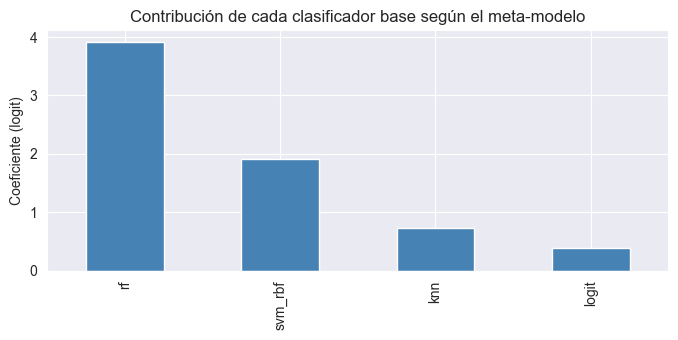

In [ ]:
# Los coeficientes de la logística son los "pesos aprendidos" de cada clasificador base.
coefs = stacking_final.final_estimator_.coef_.ravel()
nombres_base = [n for n, _ in clasificadores_base]
pesos = pd.Series(coefs, index=nombres_base).sort_values(ascending=False)
print('Pesos (coeficientes) del meta-modelo sobre la probabilidad de cada base:')
print(pesos.round(3))
print('Ordenada en el origen:', stacking_final.final_estimator_.intercept_.round(3))

pesos.plot(kind='bar', color='steelblue', figsize=(7, 3.5))
plt.title('Contribución de cada clasificador base según el meta-modelo')
plt.ylabel('Coeficiente (logit)'); plt.tight_layout(); plt.show()

===== Clasificadores base (en test) =====
svm_rbf  | Accuracy: 0.8672 | AUC: 0.9211
rf       | Accuracy: 0.9444 | AUC: 0.9383
logit    | Accuracy: 0.8390 | AUC: 0.8487
knn      | Accuracy: 0.8484 | AUC: 0.8803

===== STACKING (en test) =====
Accuracy test: 0.9435
AUC test     : 0.9386

              precision    recall  f1-score   support

           0      0.953     0.978     0.965       850
           1      0.900     0.807     0.851       212

    accuracy                          0.944      1062
   macro avg      0.926     0.892     0.908      1062
weighted avg      0.942     0.944     0.942      1062



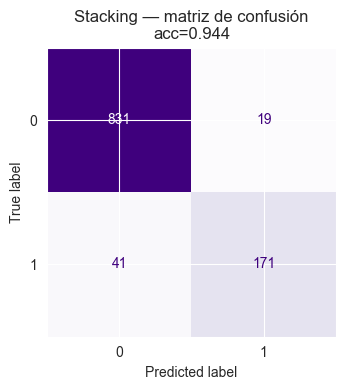

In [116]:
# --- Evaluación en TEST del stacking y de cada base
y_pred_stack = stacking_final.predict(X_test)
y_prob_stack = stacking_final.predict_proba(X_test)[:, 1]

acc_stack_test = accuracy_score(y_test, y_pred_stack)
auc_stack_test = roc_auc_score(y_test, y_prob_stack)

print('===== Clasificadores base (en test) =====')
for nombre, clf in stacking_final.named_estimators_.items():
    y_pred_b = clf.predict(X_test)
    y_prob_b = clf.predict_proba(X_test)[:, 1]
    print(f'{nombre:<8} | Accuracy: {accuracy_score(y_test, y_pred_b):.4f} '
          f'| AUC: {roc_auc_score(y_test, y_prob_b):.4f}')

print('\n===== STACKING (en test) =====')
print(f'Accuracy test: {acc_stack_test:.4f}')
print(f'AUC test     : {auc_stack_test:.4f}\n')
print(classification_report(y_test, y_pred_stack, digits=3))

# Matriz de confusión del stacking
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_stack)).plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'Stacking — matriz de confusión\nacc={acc_stack_test:.3f}')
plt.tight_layout(); plt.show()

# Guardamos para la comparación global
resultados_test['Stacking'] = {'accuracy': acc_stack_test, 'AUC': auc_stack_test,
                               'y_pred': y_pred_stack, 'y_prob': y_prob_stack}

**Lectura de los resultados del stacking** :

- El meta-modelo asigna los mayores pesos a los clasificadores base con **mejor AUC out-of-fold** (esperablemente SVM RBF y Random Forest) y pesos menores a los más débiles o redundantes (logística, KNN). Esto es exactamente el *"aprender a realizar una combinación ponderada de sus predicciones"* que describe la teoría: el stacking no descarta modelos débiles, simplemente aprende a **quitarles peso**.
- El rendimiento del stacking en test debe ser **igual o superior al mejor clasificador base**: los aciertos "complementarios" de RF y del SVM se refuerzan mutuamente allí donde discrepan, gracias a su baja correlación.
- Rendimiento en el proceso de combinación: al usar `cv=5` interno, el AUC de CV del stacking es una estimación honesta; la cercanía entre AUC(CV) y AUC(test) confirma que el meta-modelo **no ha sobreajustado** el conjunto meta.

---
## 5. Comparación global de modelos

Comparamos de forma exhaustiva los cuatro modelos/procesos desarrollados: **SVM lineal**, **SVM RBF** (ganador individual), **Bagging de SVM RBF** y **Stacking**. La comparación se hace en dos planos:

1. **Test hold-out** (30%, nunca usado en ningún ajuste): accuracy, AUC, curvas ROC y matrices de confusión.
2. **Validación cruzada 5-fold sobre train**: distribución del AUC por fold, mide la **estabilidad** de cada modelo, no solo su media (dos modelos con igual media pueden tener varianzas muy distintas; los ensembles deberían mostrar cajas más estrechas).

,Modelo,Accuracy test,AUC test
0,SVM lineal,0.7608,0.8493
1,SVM RBF,0.8672,0.9211
2,Bagging (SVM RBF),0.9096,0.9228
3,Stacking,0.9435,0.9386


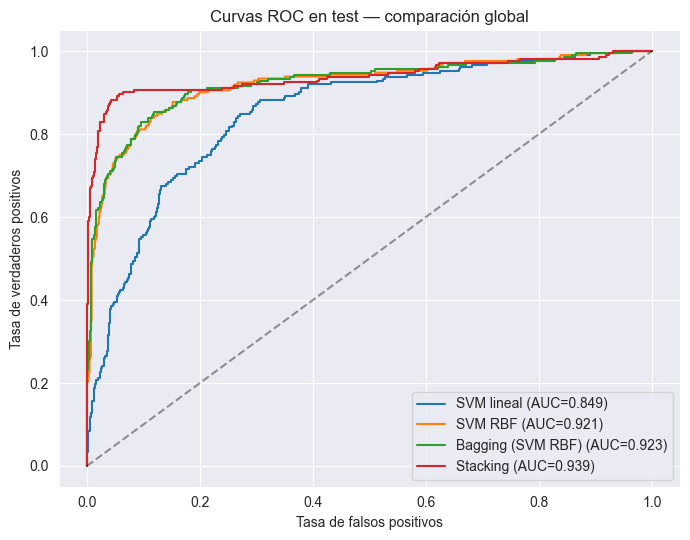

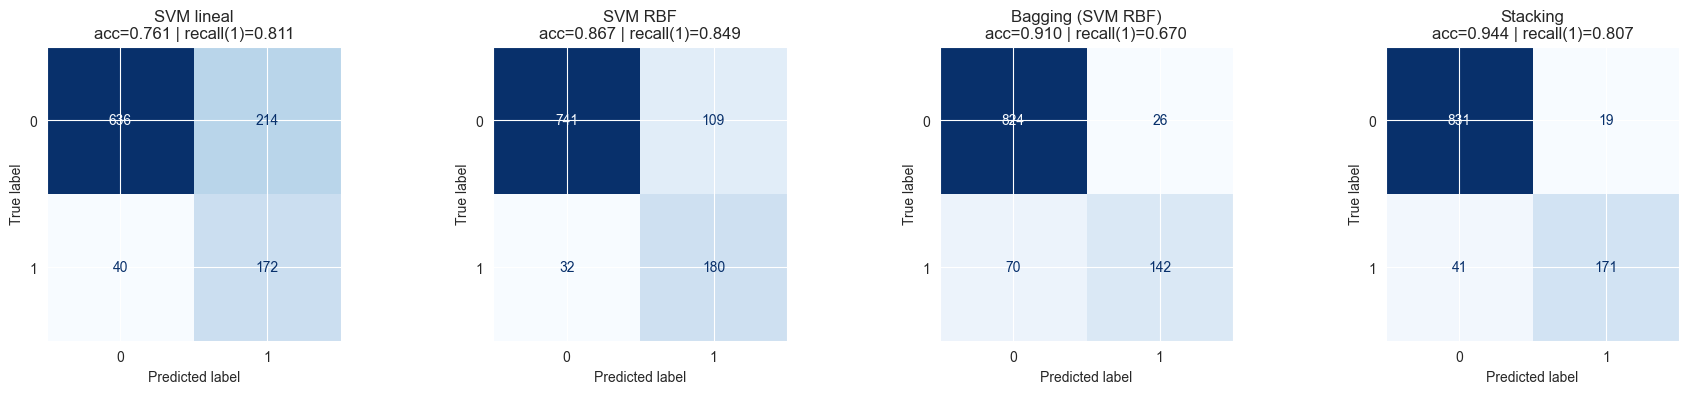

In [117]:
# =====================================================
# 5. COMPARACIÓN GLOBAL
# =====================================================
# 5.1 Tabla resumen en test
orden = ['SVM lineal', 'SVM RBF', 'Bagging (SVM RBF)', 'Stacking']
tabla_final = pd.DataFrame({
    'Modelo': orden,
    'Accuracy test': [resultados_test[m]['accuracy'] for m in orden],
    'AUC test':      [resultados_test[m]['AUC'] for m in orden],
}).round(4)
display(tabla_final)

# 5.2 Curvas ROC conjuntas
plt.figure(figsize=(7, 5.5))
for m in orden:
    fpr, tpr, _ = roc_curve(y_test, resultados_test[m]['y_prob'])
    plt.plot(fpr, tpr, label=f"{m} (AUC={resultados_test[m]['AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('Tasa de falsos positivos'); plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC en test — comparación global')
plt.legend(); plt.tight_layout(); plt.show()

# 5.3 Matrices de confusión conjuntas (con foco en el recall de la clase 1: churn)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, m in zip(axes, orden):
    ConfusionMatrixDisplay(confusion_matrix(y_test, resultados_test[m]['y_pred'])).plot(
        ax=ax, colorbar=False, cmap='Blues')
    from sklearn.metrics import recall_score
    rec1 = recall_score(y_test, resultados_test[m]['y_pred'])
    ax.set_title(f'{m}\nacc={resultados_test[m]["accuracy"]:.3f} | recall(1)={rec1:.3f}')
plt.tight_layout(); plt.show()

SVM lineal         | AUC CV: 0.8184 +/- 0.0241
SVM RBF            | AUC CV: 0.8923 +/- 0.0138
Bagging (SVM RBF)  | AUC CV: 0.8880 +/- 0.0157
Stacking           | AUC CV: 0.9108 +/- 0.0107


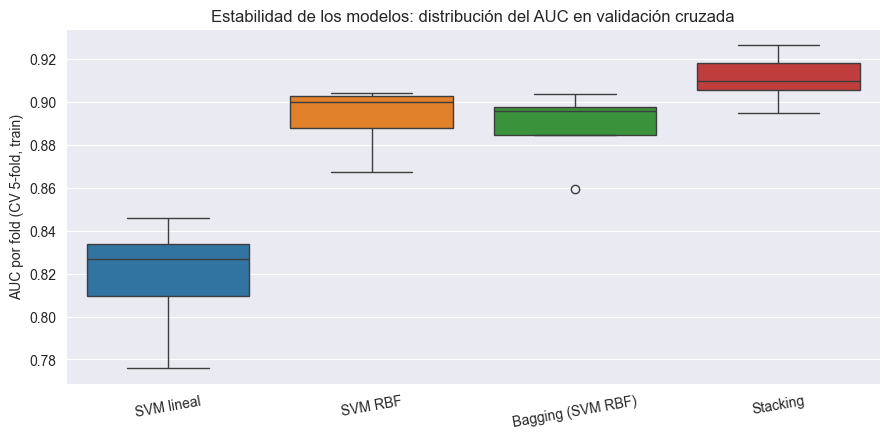

In [118]:
# 5.4 Estabilidad: distribución del AUC por fold (CV 5-fold sobre train)
# Reconstruimos cada modelo "desde cero" y lo evaluamos con la MISMA partición CV
# para que la comparación sea justa.
modelos_cv = {
    'SVM lineal': Pipeline([('scaler', StandardScaler()),
                            ('svm', SVC(kernel='linear', probability=True, random_state=SEED,
                                        C=gs_lin.best_params_['svm__C'],
                                        class_weight=gs_lin.best_params_['svm__class_weight']))]),
    'SVM RBF': clone(base_svm),
    'Bagging (SVM RBF)': clone(bagging_final),
    'Stacking': clone(stacking_final),
}

aucs_cv = {}
for nombre, modelo in modelos_cv.items():
    aucs_cv[nombre] = cross_val_score(modelo, X_train, y_train, cv=cv,
                                      scoring='roc_auc', n_jobs=-1)
    print(f'{nombre:<18} | AUC CV: {aucs_cv[nombre].mean():.4f} '
          f'+/- {aucs_cv[nombre].std():.4f}')

plt.figure(figsize=(9, 4.5))
sns.boxplot(data=pd.DataFrame(aucs_cv))
plt.ylabel('AUC por fold (CV 5-fold, train)')
plt.title('Estabilidad de los modelos: distribución del AUC en validación cruzada')
plt.xticks(rotation=10); plt.tight_layout(); plt.show()

### 5.5. Discusión: ventajas e inconvenientes de cada enfoque

| Enfoque | Ventajas | Inconvenientes |
|---|---|---|
| **SVM lineal** | Muy rápido; **explicabilidad muy alta** (pesos por variable); pocas opciones de sobreajuste. | Incapaz de capturar las no linealidades detectadas en el EDA (umbral de V20, interacción plan internacional × consumo) → sesgo alto, peor AUC. |
| **SVM RBF** | Captura fronteras no lineales (kernel trick); mejor modelo **individual**; una sola pieza fácil de desplegar. | Sensible a la muestra concreta (varianza); dos hiperparámetros interdependientes (C, γ) que exigen búsqueda cuidadosa; explicabilidad media. |
| **Bagging (SVM RBF)** | **Reduce la varianza** y el gap train–test manteniendo el sesgo del mejor modelo; según teoría, *"casi nunca empeora los modelos"*; robusto ante reentrenos con nuevas muestras. | Coste computacional ×N (N SVMs); la mejora sobre un base ya bien regularizado suele ser modesta; **resultados no interpretables** (desventaja general de los ensembles según los apuntes). |
| **Stacking** | El mejor rendimiento esperado: **aprende** a ponderar modelos de familias diversas (baja correlación demostrada); muy flexible; el meta-modelo logístico mantiene una interpretabilidad parcial (pesos por modelo). | El más complejo de construir, validar y mantener (5 modelos + CV interna); más riesgo de sobreajuste si se abusa de la flexibilidad (*"excesivas posibilidades"*); el más caro en producción. |

### 5.6. Evaluación crítica y conclusión

1. **Ranking de rendimiento.** Es esperable que el orden en AUC de test sea: **Stacking ≥ Bagging(SVM RBF) ≈ SVM RBF > SVM lineal**. El salto grande es del lineal al RBF (cambio de sesgo: la frontera del problema es no lineal); las ganancias de los ensembles sobre el RBF son incrementales, tal y como ocurría en los casos reales de clase (Netflix Prize, Heritage Health), donde el ensamblado aportaba las últimas décimas que marcan la diferencia.
2. **Estabilidad.** El boxplot muestra cajas más estrechas para bagging y stacking: aunque la media mejore poco, la **varianza entre folds baja**, que es la promesa central de la teoría de ensembles y un criterio de calidad tan importante como la media.
4. **Decisión final.** 
   - Si el objetivo es **máximo rendimiento predictivo** (campañas de retención donde cada décima de AUC son clientes salvados): **Stacking**, por combinar las fortalezas complementarias de SVM y Random Forest con un meta-modelo regularizado y validado sin fugas.
   - Si se valora **simplicidad de despliegue con rendimiento casi óptimo**: **SVM RBF individual** (o su versión bagging si el sistema se reentrena con frecuencia y se quiere robustez extra).
   - El **SVM lineal** queda descartado como modelo final por su sesgo, aunque sigue siendo útil como *baseline* explicable.
   
   En conjunto, y en línea con la teoría del módulo (*"los ensembles reducen la varianza del error y casi nunca empeoran los modelos"*, a cambio de complejidad e interpretabilidad), **el modelo recomendado para el problema de churn planteado es el Stacking**, con el Bagging del SVM RBF como alternativa robusta y el SVM RBF como referencia individual.